# Приоритизация лидов: скоринг вероятности успешного целевого действия

Поток обращений (лидов) назначается операторам колл-центров или партнёрам. Для каждого лида
в момент назначения нужно оценить вероятность успешного целевого действия в течение 5 дней
(`target = 1`) — score используется для приоритизации: перспективные лиды обрабатываются первыми.

**Метрика — Daily Average Precision**: Average Precision считается отдельно внутри каждой даты
назначения, затем усредняется по дням. Оценивается качество ранжирования внутри дня, поэтому
калибровка вероятностей не важна — важен только порядок score.

**Ключевое ограничение**: признаки строятся только из информации, доступной на момент
назначения (`assignment_ts`). Для событий из `events.csv` — жёсткий фильтр
`event_ts < assignment_ts`, использование более поздних событий считается утечкой.

## Этап 1. Подготовка среды и библиотек
1. Импортируем библиотеки. Версии зафиксированы в `requirements.txt` для воспроизводимости.
2. Фиксируем `RANDOM_STATE = 42` — используется во всех моделях и разбиениях.
3. Объявляем константы: пути к данным, список категориальных признаков, временные окна.
4. Объявляем общие функции решения — метрику `daily_average_precision` (реализация метрики
   платформы), time-based разбиения (`time_holdout`, `expanding_folds`) и построители
   признаков.


In [1]:
# Импортируем библиотеки
from pathlib import Path
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import re
from catboost import CatBoostClassifier, Pool

# Пути к данным.
ROOT = Path("..")
DATA_DIR = ROOT / "data"

TARGET = "target"

# Эти колонки не используем как признаки модели.
ID_COLUMNS = {"lead_id", "user_id"}
TIME_COLUMNS = {"assignment_ts", "assignment_date"}
NON_FEATURE_COLUMNS = ID_COLUMNS | TIME_COLUMNS | {TARGET, "split"}

RANDOM_STATE = 42

In [2]:
# Категориальные признаки
CAT_COLS = [
    "lead_source", "call_center", "region", "car_segment",
    "lead_channel", "user_tenure_bucket", "price_bucket",
]
NON_FEATURES = {"lead_id", "user_id", "assignment_ts", "assignment_date", TARGET}
# Временные окна готовых агрегатов
WINDOWS = ["1d", "3d", "7d", "14d", "30d", "90d"]

# Колонки со скрытым дробным сигналом (находка EDA, раздел 3.5)
FRAC_COLS = ["seller_page_views_7d", "seller_page_views_14d", "seller_page_views_30d"]

# События: типы и окна (глубина истории в events - около 30 дней)
EVENT_TYPES = ["item_view", "search", "favorite", "chat_open", "call_click"]
EV_WINDOWS = {"3d": 3, "7d": 7, "14d": 14, "30d": 30}

In [3]:
def cast_types(df):
    """Приведение типов: даты -> datetime, категориальные признаки -> category."""
    df = df.copy()
    df["assignment_ts"] = pd.to_datetime(df["assignment_ts"])
    df["assignment_date"] = pd.to_datetime(df["assignment_date"])
    for c in CAT_COLS:
        df[c] = df[c].astype("category")
    return df


def daily_average_precision(y_true, y_score, dates):
    """Метрика платформы: AP отдельно по каждому дню, затем среднее по дням.
    Дни без положительных примеров пропускаются (AP не определен)."""
    df = pd.DataFrame({"y": np.asarray(y_true), "s": np.asarray(y_score),
                       "d": np.asarray(dates)})
    aps = [average_precision_score(g["y"], g["s"])
           for _, g in df.groupby("d") if g["y"].sum() > 0]
    return float(np.mean(aps))


def time_holdout(df, n_val_days=4):
    """Time-based split: последние n_val_days дней -> валидация."""
    days = np.sort(df["assignment_date"].unique())
    mask = df["assignment_date"].isin(days[-n_val_days:])
    return df[~mask].copy(), df[mask].copy()


def expanding_folds(df, val_len=3, n_folds=3):
    """Expanding window CV: обучение растет, валидация сдвигается к концу периода."""
    days = np.sort(df["assignment_date"].unique())
    folds = []
    for i in range(n_folds):
        val_end = len(days) - (n_folds - 1 - i) * val_len
        val_days = days[val_end - val_len:val_end]
        tr = df[df["assignment_date"] < val_days[0]]
        va = df[df["assignment_date"].isin(val_days)]
        folds.append((tr.copy(), va.copy()))
    return folds


def add_frac_features(df):
    """Признаки из аномалии, найденной в EDA (раздел 3.5).

    Колонки seller_page_views_7d/14d/30d - счетчики просмотров, но часть
    значений в них дробная (например 5.37 вместо 5). Анализ показал, что
    дробная часть связана с целевой переменной: у строк с дробным значением
    конверсия заметно выше, а округление этих колонок ухудшает Daily AP на ~7 п.п.

    Поэтому выделяем скрытый сигнал в явные признаки:
    - {col}_frac     - дробная часть значения (5.37 -> 0.37);
    - {col}_has_frac - флаг "значение содержит дробную часть" (0/1).
    """
    df = df.copy()
    for c in FRAC_COLS:
        df[f"{c}_frac"] = df[c] % 1
        df[f"{c}_has_frac"] = (df[c] % 1 > 0).astype(float)
    return df


def build_event_features(events, base_df):
    """Признаки из сырых событий. Анти-утечка: только события до назначения лида."""
    ev = events.merge(base_df[["lead_id", "assignment_ts", "item_price_log"]]
                      .rename(columns={"item_price_log": "lead_price_log"}),
                      on="lead_id", how="inner")
    ev = ev[ev["event_ts"] < ev["assignment_ts"]].copy()
    assert (ev["event_ts"] < ev["assignment_ts"]).all(), "утечка: события после назначения"

    ev["hours_before"] = (ev["assignment_ts"] - ev["event_ts"]).dt.total_seconds() / 3600
    g = ev.groupby("lead_id")
    feats = pd.DataFrame(index=g.size().index)

    # Счетчики событий каждого типа за 3/7/14/30 дней ДО назначения.
    # Пример: ev_call_click_7d = сколько раз пользователь кликнул "позвонить"
    # за последние 7 дней перед назначением лида.
    for w, days in EV_WINDOWS.items():
        in_w = ev[ev["hours_before"] <= days * 24]
        cnt = in_w.pivot_table(index="lead_id", columns="event_type",
                               aggfunc="size", fill_value=0)
        cnt = cnt.reindex(columns=EVENT_TYPES, fill_value=0)
        cnt.columns = [f"ev_{t}_{w}" for t in cnt.columns]
        feats = feats.join(cnt, how="left")

    # Давность последнего события каждого типа: сколько часов прошло
    # от последнего события до момента назначения лида.
    # Пример: ev_hours_since_call_click = 5 означает "кликал по звонку
    # за 5 часов до назначения" (недавняя активность - горячий лид).
    last = ev.pivot_table(index="lead_id", columns="event_type",
                          values="hours_before", aggfunc="min").reindex(columns=EVENT_TYPES)
    last.columns = [f"ev_hours_since_{t}" for t in last.columns]
    feats = feats.join(last)

    # Общий объем активности: всего событий у лида, часов с последнего
    # события любого типа, и глубина доступной истории (часов от самого
    # раннего события до назначения).
    feats["ev_total"] = g.size()
    feats["ev_hours_since_any"] = g["hours_before"].min()
    feats["ev_history_depth_h"] = g["hours_before"].max()

    # Динамика интереса: какая доля событий последнего месяца пришлась
    # на последнюю неделю. Значение ~0.25 - активность ровная,
    # ближе к 1 - интерес разгорается, ближе к 0 - затухает.
    # (+1 в знаменателе - защита от деления на ноль)
    feats["ev_trend_7_30"] = (sum(feats[f"ev_{t}_7d"] for t in EVENT_TYPES)
                              / (sum(feats[f"ev_{t}_30d"] for t in EVENT_TYPES) + 1))

    # Разнообразие поведения: сколько разных слотов (src_slot) и контекстов
    # показа (ctx_seq) встречается в событиях лида. Широкое разнообразие -
    # признак активного целенаправленного поиска.
    feats["ev_n_slots"] = g["src_slot"].nunique()
    feats["ev_n_ctx"] = g["ctx_seq"].nunique()

    # Ценовой профиль: насколько средняя цена просмотренных объявлений
    # отличается от цены объекта самого лида, и как широк разброс цен
    # просмотренного (узкий - выбор сделан, широкий - еще сравнивает).
    feats["ev_price_mean_diff"] = g["item_price_log"].mean() - g["lead_price_log"].first()
    feats["ev_price_std"] = g["item_price_log"].std()
    return feats

In [4]:
def run_cv(df, cols, cat_cols, n_folds=3, val_len=3, label=""):
    """Expanding window CV: обучение CatBoost на каждом фолде, метрика - Daily AP.
    Используется для контроля решений, принятых по одному holdout."""
    scores = []
    for i, (tr, va) in enumerate(expanding_folds(df, val_len=val_len, n_folds=n_folds)):
        m = CatBoostClassifier(iterations=5000, learning_rate=0.01, depth=6,
                               loss_function="Logloss", eval_metric="PRAUC",
                               random_seed=RANDOM_STATE, early_stopping_rounds=200,
                               verbose=0)
        m.fit(Pool(tr[cols], tr[TARGET], cat_features=cat_cols),
              eval_set=Pool(va[cols], va[TARGET], cat_features=cat_cols))
        s = m.predict_proba(va[cols])[:, 1]
        dap = daily_average_precision(va[TARGET], s, va["assignment_date"])
        scores.append(dap)
        print(f"{label} fold {i+1}: {dap:.5f} "
              f"(val: {va['assignment_date'].dt.date.min()}—{va['assignment_date'].dt.date.max()})")
    print(f"{label} mean: {np.mean(scores):.5f} ± {np.std(scores):.5f}\n")
    return scores

## Этап 2. Загрузка данных

1. Загружаем обучающую выборку, тестовую выборку и события.
2. Приводим типы: `assignment_ts`, `assignment_date`, `event_ts` → datetime
   (нужны для time-based валидации и фильтра утечки), 7 признаков контекста
   назначения → category (для нативной обработки в CatBoost).

| Файл | Строк | Период | Назначение |
|---|---|---|---|
| train.csv | 13 694 | 07.04–22.04 (16 дней) | обучение, есть `target` (доля позитивов 20.8%) |
| test.csv | 4 306 | 23.04–27.04 (5 дней) | скоринг для submission, без `target` |
| events.csv | 254 705 | с 08.03 | сырые события для feature engineering |

Одна строка train/test — одно назначенное обращение (лид). Тест находится
строго позже train по времени, пересечения пользователей между выборками нет.

In [5]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
events = pd.read_csv(DATA_DIR / "events.csv")

In [6]:
display(train)

,lead_id,user_id,assignment_ts,assignment_date,lead_source,call_center,region,car_segment,lead_channel,user_tenure_bucket,...,leadgen_prev_positive_14d,leadgen_prev_positive_30d,leadgen_prev_positive_90d,active_days_auto_1d,active_days_auto_3d,active_days_auto_7d,active_days_auto_14d,active_days_auto_30d,active_days_auto_90d,target
0,lead_f57db09ab39ae3e7,user_0000001,2026-04-22 11:56:00,2026-04-22,CRM,external,west,budget,retargeting,warm,...,0.0,0.0,0.0,0.0,0.0,0.0,4.0,9.0,26.0,0
1,lead_a6184b8a8165a27b,user_0000002,2026-04-07 14:49:00,2026-04-07,CRM,voxys,north,standard,partner,warm,...,0.0,NaN,1.0,0.0,0.0,0.0,NaN,4.0,5.0,0
2,lead_229c2a117dbac203,user_0000003,2026-04-12 17:01:00,2026-04-12,Perf,external,north,budget,retargeting,new,...,0.0,0.0,NaN,2.0,4.0,1.0,10.0,12.0,52.0,0
3,lead_16b19e58042ef905,user_0000005,2026-04-13 21:39:00,2026-04-13,Model,voxys,east,premium,partner,warm,...,0.0,1.0,0.0,0.0,1.0,0.0,3.0,2.0,NaN,1
4,lead_734c227324978a36,user_0000006,2026-04-12 18:01:00,2026-04-12,CRM,voxys,central,budget,retargeting,warm,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,9.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13689,lead_ef26f2bac902099c,user_0017994,2026-04-09 13:23:00,2026-04-09,Model,voxys,north,budget,app,new,...,0.0,0.0,0.0,0.0,NaN,1.0,1.0,3.0,11.0,0
13690,lead_8cc1895a7c4fdd2c,user_0017995,2026-04-14 17:08:00,2026-04-14,CRM,external,north,standard,retargeting,loyal,...,0.0,0.0,0.0,0.0,0.0,1.0,2.0,4.0,6.0,0
13691,lead_2fac42d232431f0e,user_0017997,2026-04-13 15:44:00,2026-04-13,Perf,voxys,east,standard,partner,warm,...,0.0,1.0,0.0,0.0,2.0,2.0,4.0,5.0,18.0,0
13692,lead_850e309d1de0db48,user_0017998,2026-04-22 14:21:00,2026-04-22,CRM,voxys,central,commercial,retargeting,new,...,0.0,0.0,0.0,0.0,2.0,0.0,1.0,3.0,5.0,0


In [7]:
display(test)

,lead_id,user_id,assignment_ts,assignment_date,lead_source,call_center,region,car_segment,lead_channel,user_tenure_bucket,...,leadgen_prev_positive_7d,leadgen_prev_positive_14d,leadgen_prev_positive_30d,leadgen_prev_positive_90d,active_days_auto_1d,active_days_auto_3d,active_days_auto_7d,active_days_auto_14d,active_days_auto_30d,active_days_auto_90d
0,lead_97e409eb8f8c8246,user_0000000,2026-04-27 13:09:00,2026-04-27,CRM,voxys,north,commercial,retargeting,new,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,2.0,9.0,34.0
1,lead_55310edb4489f9e9,user_0000004,2026-04-24 14:48:00,2026-04-24,Model,voxys,east,standard,retargeting,warm,...,0.0,0.0,1.0,0.0,0.0,0.0,2.0,1.0,6.0,12.0
2,lead_e7f653a2c6a7eee8,user_0000019,2026-04-27 16:00:00,2026-04-27,Model,voxys,west,commercial,app,new,...,0.0,0.0,1.0,0.0,1.0,3.0,4.0,3.0,2.0,21.0
3,lead_22f8e1cfc487ac20,user_0000021,2026-04-27 11:56:00,2026-04-27,Model,external,north,commercial,web,loyal,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,3.0,11.0
4,lead_48b638b839abfac3,user_0000023,2026-04-26 10:13:00,2026-04-26,CRM,voxys,east,standard,app,warm,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0,4.0,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4301,lead_bdf0d11f7e3d1bf0,user_0017980,2026-04-23 18:17:00,2026-04-23,Perf,external,south,budget,retargeting,new,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0
4302,lead_be9c23747b399866,user_0017984,2026-04-25 17:42:00,2026-04-25,Perf,voxys,east,budget,app,new,...,0.0,1.0,0.0,0.0,NaN,0.0,0.0,2.0,NaN,12.0
4303,lead_410162fac12fdfb9,user_0017987,2026-04-27 20:40:00,2026-04-27,Model,voxys,east,commercial,web,warm,...,0.0,0.0,0.0,1.0,0.0,0.0,4.0,2.0,5.0,7.0
4304,lead_10c42c2506df70fb,user_0017989,2026-04-26 17:17:00,2026-04-26,Model,external,east,budget,retargeting,warm,...,0.0,0.0,NaN,0.0,0.0,0.0,0.0,1.0,3.0,10.0


In [8]:
train.info(verbose=True, show_counts=True) 

<class 'pandas.DataFrame'>
RangeIndex: 13694 entries, 0 to 13693
Data columns (total 119 columns):
 #    Column                     Non-Null Count  Dtype  
---   ------                     --------------  -----  
 0    lead_id                    13694 non-null  str    
 1    user_id                    13694 non-null  str    
 2    assignment_ts              13694 non-null  str    
 3    assignment_date            13694 non-null  str    
 4    lead_source                13694 non-null  str    
 5    call_center                13694 non-null  str    
 6    region                     13694 non-null  str    
 7    car_segment                13694 non-null  str    
 8    lead_channel               13694 non-null  str    
 9    user_tenure_bucket         13694 non-null  str    
 10   price_bucket               13694 non-null  str    
 11   assignment_hour            13694 non-null  float64
 12   assignment_weekday         13694 non-null  float64
 13   is_weekend                 13694 non-nul

In [9]:
display(events)

,lead_id,user_id,event_ts,event_type,item_price_log,src_slot,ctx_seq
0,lead_00025e9610a0d90d,user_0016636,2026-03-27 06:41:00,chat_open,13.303438,19.0,c02
1,lead_00025e9610a0d90d,user_0016636,2026-03-31 09:10:00,item_view,13.322707,6.0,c06
2,lead_00025e9610a0d90d,user_0016636,2026-04-02 22:04:00,item_view,13.395721,10.0,c06
3,lead_00025e9610a0d90d,user_0016636,2026-04-04 09:19:00,search,13.395955,10.0,c04
4,lead_00025e9610a0d90d,user_0016636,2026-04-07 12:36:00,item_view,13.472769,2.0,c02
...,...,...,...,...,...,...,...
254700,lead_fffa6c127a83c9d3,user_0004502,2026-04-12 23:03:00,item_view,13.027277,11.0,c08
254701,lead_fffa6c127a83c9d3,user_0004502,2026-04-16 05:23:00,item_view,13.242283,6.0,c04
254702,lead_fffa6c127a83c9d3,user_0004502,2026-04-16 13:29:00,item_view,13.080168,21.0,c08
254703,lead_fffa6c127a83c9d3,user_0004502,2026-04-21 08:56:00,call_click,13.272838,17.0,c01


In [10]:
events.info()

<class 'pandas.DataFrame'>
RangeIndex: 254705 entries, 0 to 254704
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   lead_id         254705 non-null  str    
 1   user_id         254705 non-null  str    
 2   event_ts        254705 non-null  str    
 3   event_type      254705 non-null  str    
 4   item_price_log  254705 non-null  float64
 5   src_slot        254705 non-null  float64
 6   ctx_seq         254705 non-null  str    
dtypes: float64(2), str(5)
memory usage: 13.6 MB


In [11]:
# Приведение типов: даты -> datetime, категориальные признаки -> category
train = cast_types(train)
test = cast_types(test)
events["event_ts"] = pd.to_datetime(events["event_ts"])

In [12]:
# Проверки согласованности данных
# 1. Дата назначения соответствует таймстемпу
assert (train["assignment_ts"].dt.date == train["assignment_date"].dt.date).all()
assert (test["assignment_ts"].dt.date == test["assignment_date"].dt.date).all()

# 2. Тест строго позже train, без перекрытия по датам
assert train["assignment_date"].max() < test["assignment_date"].min()

# 3. lead_id уникальны, пересечения пользователей train/test нет
assert train["lead_id"].is_unique and test["lead_id"].is_unique
assert len(set(train["user_id"]) & set(test["user_id"])) == 0

print("train:", train["assignment_date"].min().date(), "-", train["assignment_date"].max().date())
print("test: ", test["assignment_date"].min().date(), "-", test["assignment_date"].max().date())
print("events:", events["event_ts"].min(), "-", events["event_ts"].max())
print("target rate:", round(train[TARGET].mean(), 4))

train: 2026-04-07 - 2026-04-22
test:  2026-04-23 - 2026-04-27
events: 2026-03-08 10:03:00 - 2026-04-27 20:28:00
target rate: 0.2075


**Вывод**: типы приведены, данные согласованы. Тест — следующие 5 дней строго после train (пересечения дат и пользователей нет), т.е. задача — прогноз "в будущее": валидация должна быть time-based. События покрывают ~30 дней до первых назначений — из них можно строить признаки-окна глубиной до месяца.

## Этап 3. Первичный анализ данных

### 3.1 Целевая переменная во времени

                 n_leads  target_rate
assignment_date                      
2026-04-07           873     0.223368
2026-04-08           832     0.209135
2026-04-09           859     0.206054
2026-04-10           830     0.220482
2026-04-11           861     0.203252
2026-04-12           855     0.203509
2026-04-13           791     0.206068
2026-04-14           842     0.197150
2026-04-15           899     0.199110
2026-04-16           854     0.203747
2026-04-17           901     0.221976
2026-04-18           875     0.203429
2026-04-19           863     0.198146
2026-04-20           861     0.191638
2026-04-21           837     0.235364
2026-04-22           861     0.197445


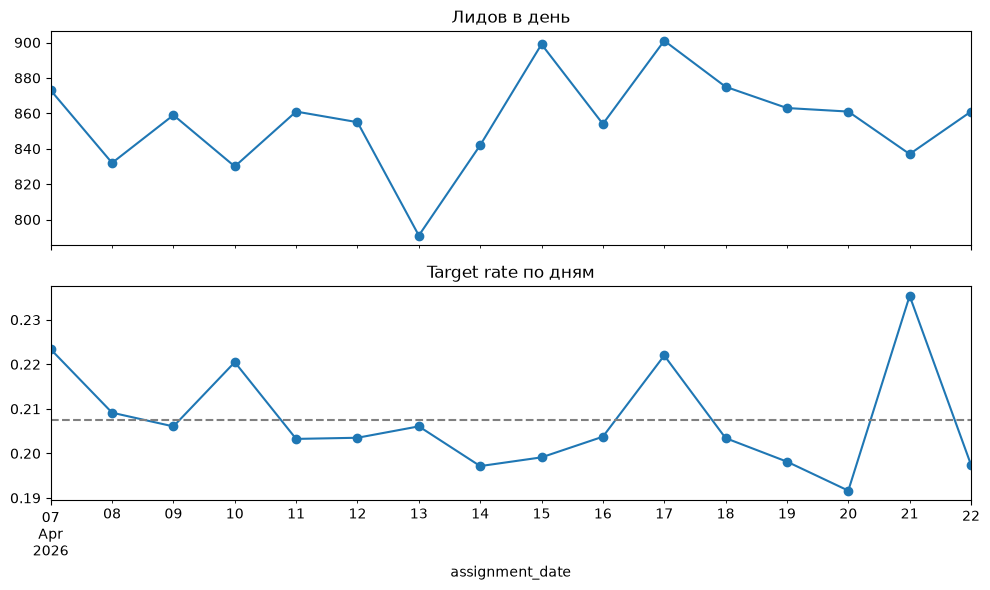

In [13]:
daily = train.groupby("assignment_date").agg(
    n_leads=("target", "size"),
    target_rate=("target", "mean"),
)
print(daily)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
daily["n_leads"].plot(ax=axes[0], marker="o", title="Лидов в день")
daily["target_rate"].plot(ax=axes[1], marker="o", title="Target rate по дням")
axes[1].axhline(train["target"].mean(), ls="--", c="gray")
plt.tight_layout()

**Вывод**: поток стабилен — 791–901 лидов/день, target rate колеблется в пределах 0.19–0.235 вокруг среднего 0.208 без тренда (при ~850 лидах/день это в границах статистического шума). Дрейфа нет → валидация на последних днях train репрезентативна.

### 3.2 Категориальные признаки и target

In [14]:
def uniques_report(df, name, top=50):
    rep = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "nunique": df.nunique(),
        "sample": [df[c].dropna().unique()[:4].tolist() for c in df.columns],
    }).sort_values("nunique")
    print(f"--- {name}: {df.shape} ---")
    print(rep.head(top))
    return rep

rep_train = uniques_report(train, "train")
rep_test = uniques_report(test, "test")
rep_events = uniques_report(events, "events")

--- train: (13694, 119) ---
                              dtype  nunique  \
target                        int64        2   
leadgen_prev_positive_3d    float64        2   
call_center                category        2   
is_weekend                  float64        2   
leadgen_prev_answered_1d    float64        3   
leadgen_prev_positive_1d    float64        3   
leadgen_prev_positive_7d    float64        3   
leadgen_prev_answered_3d    float64        3   
user_tenure_bucket         category        3   
price_bucket               category        3   
lead_source                category        3   
leadgen_prev_answered_7d    float64        3   
chat_opens_1d               float64        4   
call_clicks_1d              float64        4   
call_clicks_3d              float64        4   
user_contacts_1d            float64        4   
leadgen_prev_assigned_1d    float64        4   
saved_search_matches_1d     float64        4   
similar_item_clicks_1d      float64        4   
leadgen_prev

In [15]:
for c in CAT_COLS:
    stats = train.groupby(c, observed=True)["target"].agg(["mean", "count"])
    print(f"\n--- {c} ---\n", stats.sort_values("mean", ascending=False))
    


--- lead_source ---
                  mean  count
lead_source                 
Model        0.265295   5688
Perf         0.195137   3167
CRM          0.147551   4839

--- call_center ---
                  mean  count
call_center                 
voxys        0.232794   5812
external     0.188785   7882

--- region ---
              mean  count
region                  
north    0.212546   2710
east     0.212446   2796
west     0.207220   2770
central  0.203303   2725
south    0.201634   2693

--- car_segment ---
                  mean  count
car_segment                 
premium      0.236249   1909
budget       0.211330   4713
standard     0.201038   5780
commercial   0.179567   1292

--- lead_channel ---
                   mean  count
lead_channel                 
retargeting   0.218612   3385
app           0.214789   3408
web           0.202956   3518
partner       0.193615   3383

--- user_tenure_bucket ---
                         mean  count
user_tenure_bucket                 
new

In [16]:
# Стабильность эффектов во времени: конверсия по категориям в первой и второй половине периода train
mid = pd.Timestamp("2026-04-15")
early, late = train[train.assignment_date < mid], train[train.assignment_date >= mid]

for c in CAT_COLS:
    both = pd.concat({
        "early": early.groupby(c, observed=True)["target"].mean(),
        "late": late.groupby(c, observed=True)["target"].mean(),
    }, axis=1).round(3)
    both["diff"] = (both["late"] - both["early"]).round(3)
    print(f"\n--- {c} ---\n", both)


--- lead_source ---
              early   late   diff
lead_source                     
CRM          0.142  0.152  0.010
Model        0.264  0.266  0.002
Perf         0.208  0.182 -0.026

--- call_center ---
              early   late   diff
call_center                     
external     0.188  0.189  0.001
voxys        0.236  0.229 -0.007

--- region ---
          early   late   diff
region                      
central  0.209  0.198 -0.011
east     0.205  0.220  0.015
north    0.220  0.205 -0.015
south    0.202  0.201 -0.001
west     0.207  0.207  0.000

--- car_segment ---
              early   late   diff
car_segment                     
budget       0.214  0.209 -0.005
commercial   0.172  0.186  0.014
premium      0.229  0.243  0.014
standard     0.205  0.197 -0.008

--- lead_channel ---
               early   late   diff
lead_channel                     
app           0.217  0.213 -0.004
partner       0.197  0.191 -0.006
retargeting   0.211  0.226  0.015
web           0.210  0.196

**Вывод**: сильные и стабильные во времени сигналы — `lead_source` (Model 0.27 > Perf 0.20 > CRM 0.15), `call_center` (voxys 0.23 vs external 0.19), `car_segment` (premium 0.24 vs commercial 0.18). Единственная заметная нестабильность — снижение конверсии Perf во второй половине периода (0.21 → 0.18); остальные категории стабильны (|diff| ≤ 1.6 п.п.)`region`, `user_tenure_bucket`, `price_bucket` самостоятельного сигнала не несут, но остаются в модели (деревьям не мешают, могут сработать во взаимодействиях).

### 3.3 Числовые признаки и связь с target

In [17]:
num_cols = train.select_dtypes("number").columns.drop("target")
sig = pd.DataFrame({
    "mean_0": train.loc[train.target == 0, num_cols].mean(),
    "mean_1": train.loc[train.target == 1, num_cols].mean(),
})
sig["ratio"] = sig["mean_1"] / sig["mean_0"]
print(sig.sort_values("ratio", ascending=False).head(25))
print(sig.sort_values("ratio").head(10))

                              mean_0      mean_1     ratio
leadgen_prev_positive_14d   0.064709    0.109341  1.689744
leadgen_prev_positive_7d    0.026841    0.043194  1.609288
leadgen_prev_answered_14d   0.158449    0.252823  1.595616
leadgen_prev_positive_30d   0.128479    0.200872  1.563454
user_contacts_30d           2.210061    3.340754  1.511612
leadgen_prev_answered_1d    0.015793    0.023576  1.492838
call_clicks_14d             0.685413    1.018902  1.486553
leadgen_prev_positive_90d   0.320213    0.467806  1.460921
chat_opens_30d              1.834900    2.631980  1.434400
search_views_90d           51.628588   73.433853  1.422349
call_clicks_7d              0.356153    0.506536  1.422244
seller_page_views_7d        0.428951    0.609577  1.421086
search_views_14d            8.005420   11.374638  1.420867
saved_search_matches_3d     0.183873    0.261186  1.420468
similar_item_clicks_14d     2.624893    3.719826  1.417134
search_views_7d             4.064431    5.759219  1.4169

In [18]:
sns.set_theme(style="whitegrid", font_scale=0.9)

WINDOWS = ["1d", "3d", "7d", "14d", "30d", "90d"]
num_cols = train.select_dtypes("number").columns.drop("target")

def get_families(cols):
    """Семейства признаков, у которых есть все 6 временных окон."""
    fams = {}
    for c in cols:
        m = re.match(r"^(.+)_(1|3|7|14|30|90)d$", c)
        if m:
            fams.setdefault(m.group(1), set()).add(m.group(2) + "d")
    return sorted(f for f, ws in fams.items() if ws == set(WINDOWS))

FAMILIES = get_families(num_cols)
print(f"{len(FAMILIES)} семейств:", FAMILIES)

16 семейств: ['active_days_auto', 'call_clicks', 'chat_opens', 'detail_expands', 'item_favorites', 'item_views', 'leadgen_prev_answered', 'leadgen_prev_assigned', 'leadgen_prev_positive', 'photo_swipes', 'query_refinements', 'saved_search_matches', 'search_views', 'seller_page_views', 'similar_item_clicks', 'user_contacts']


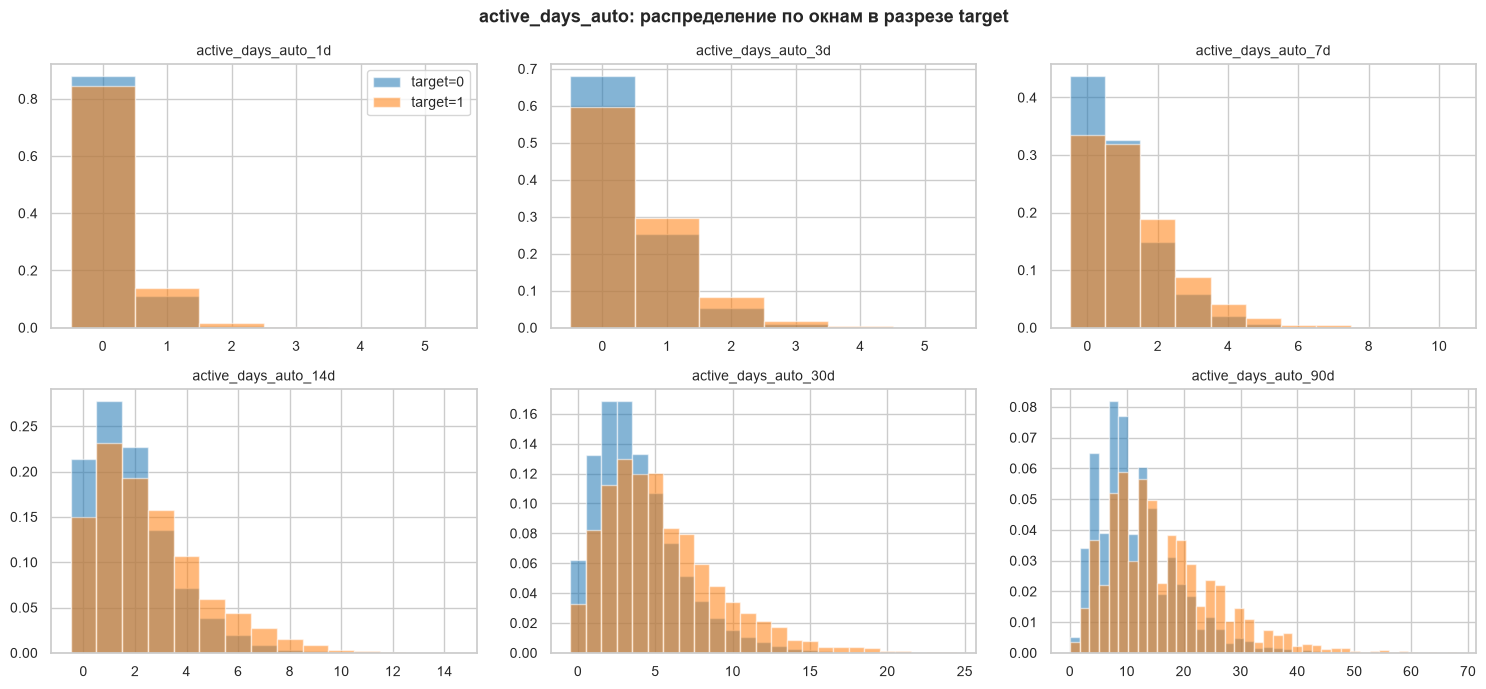

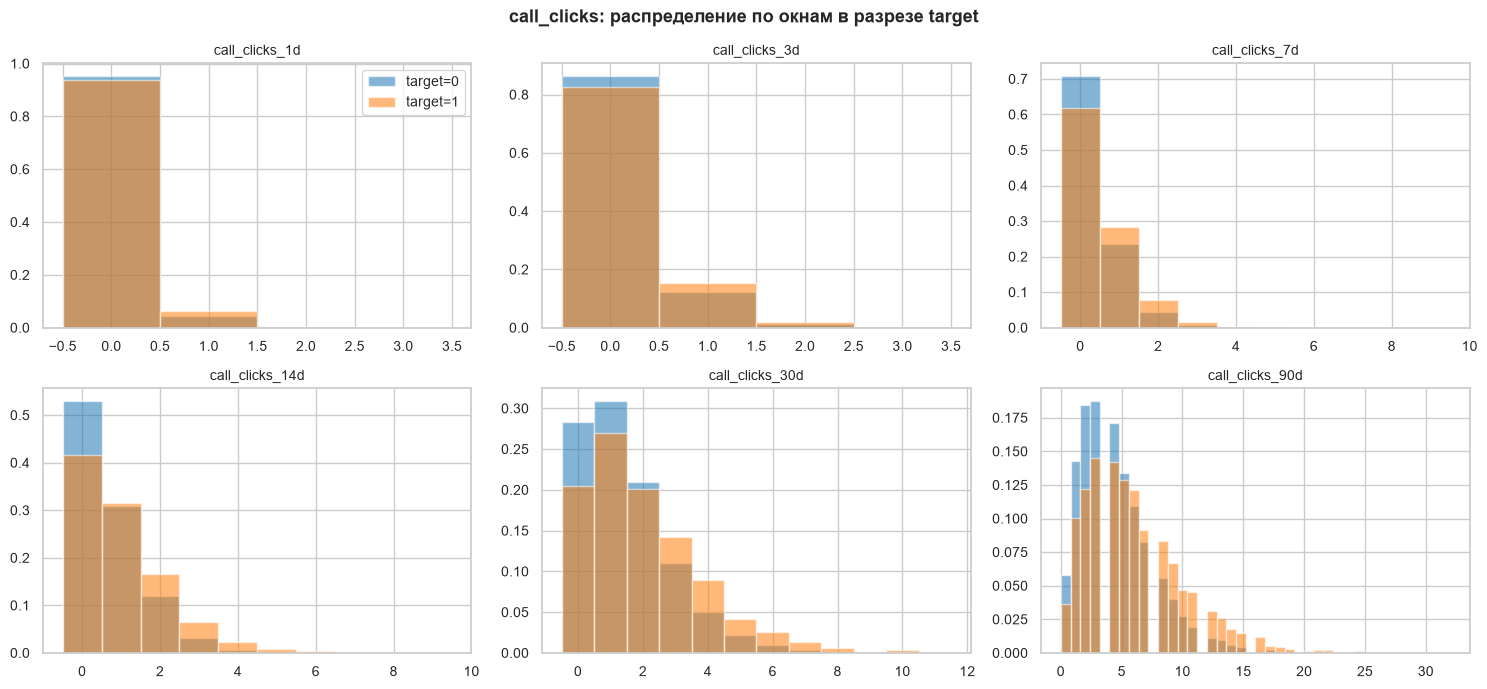

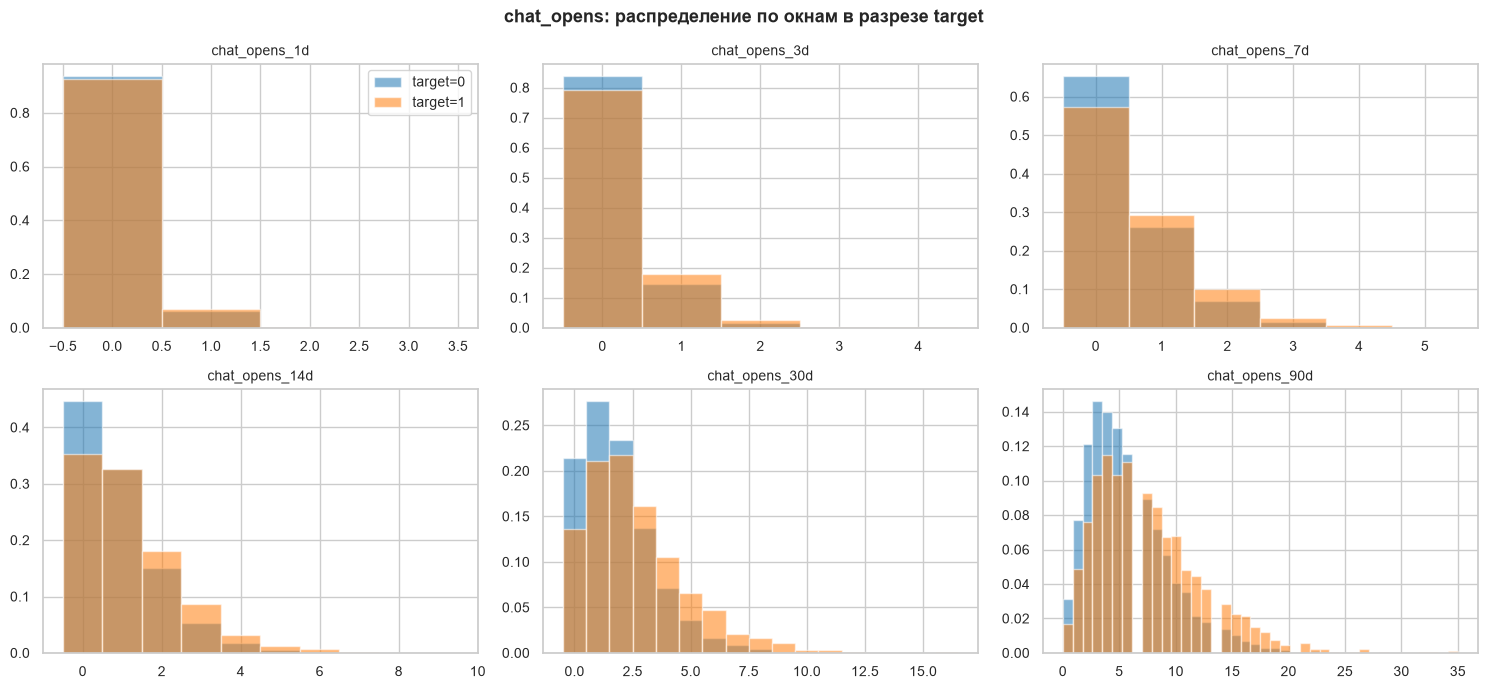

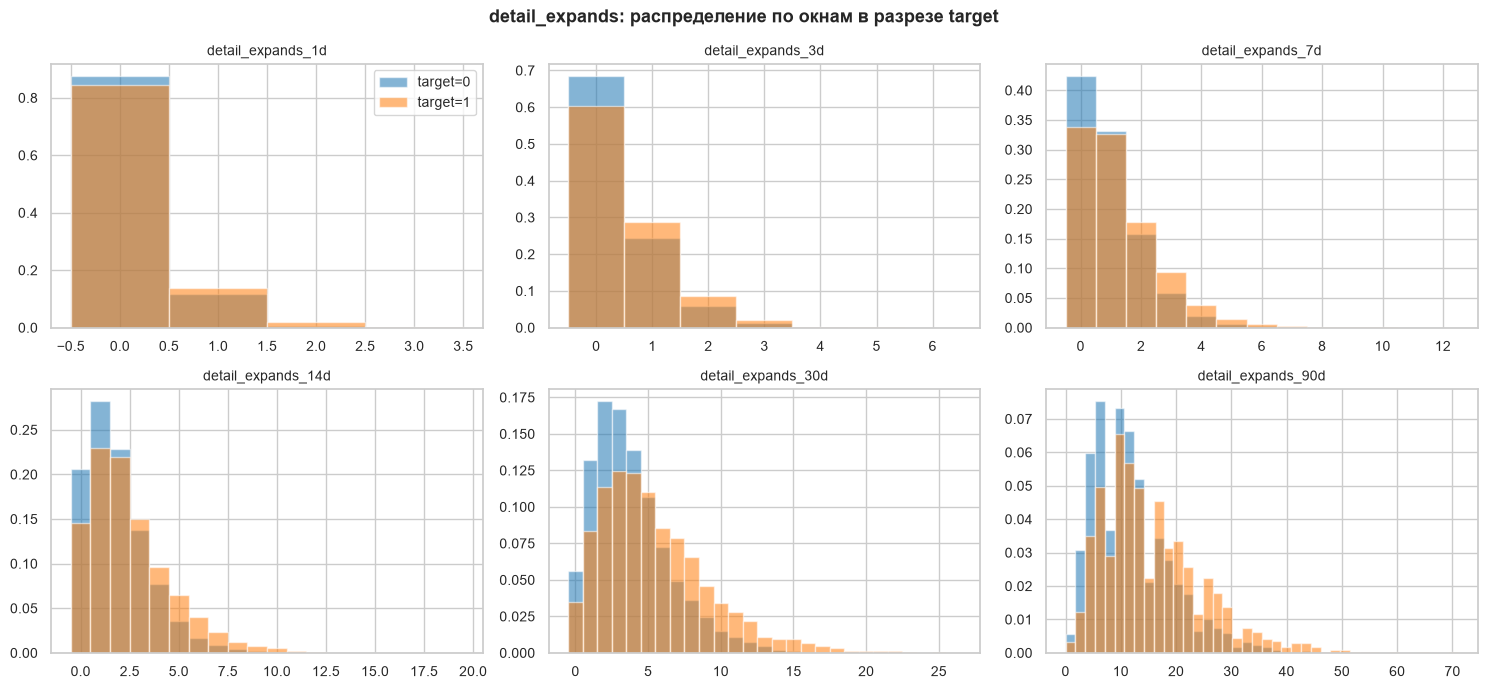

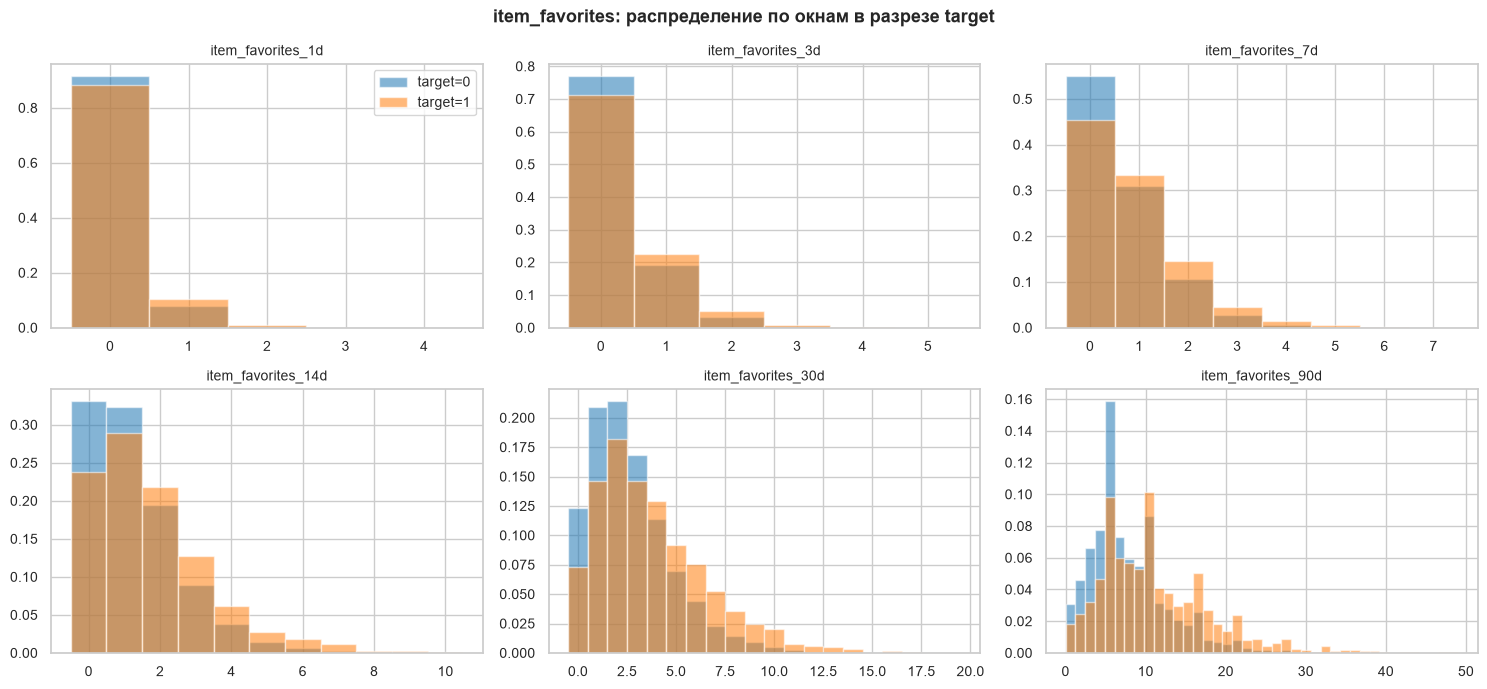

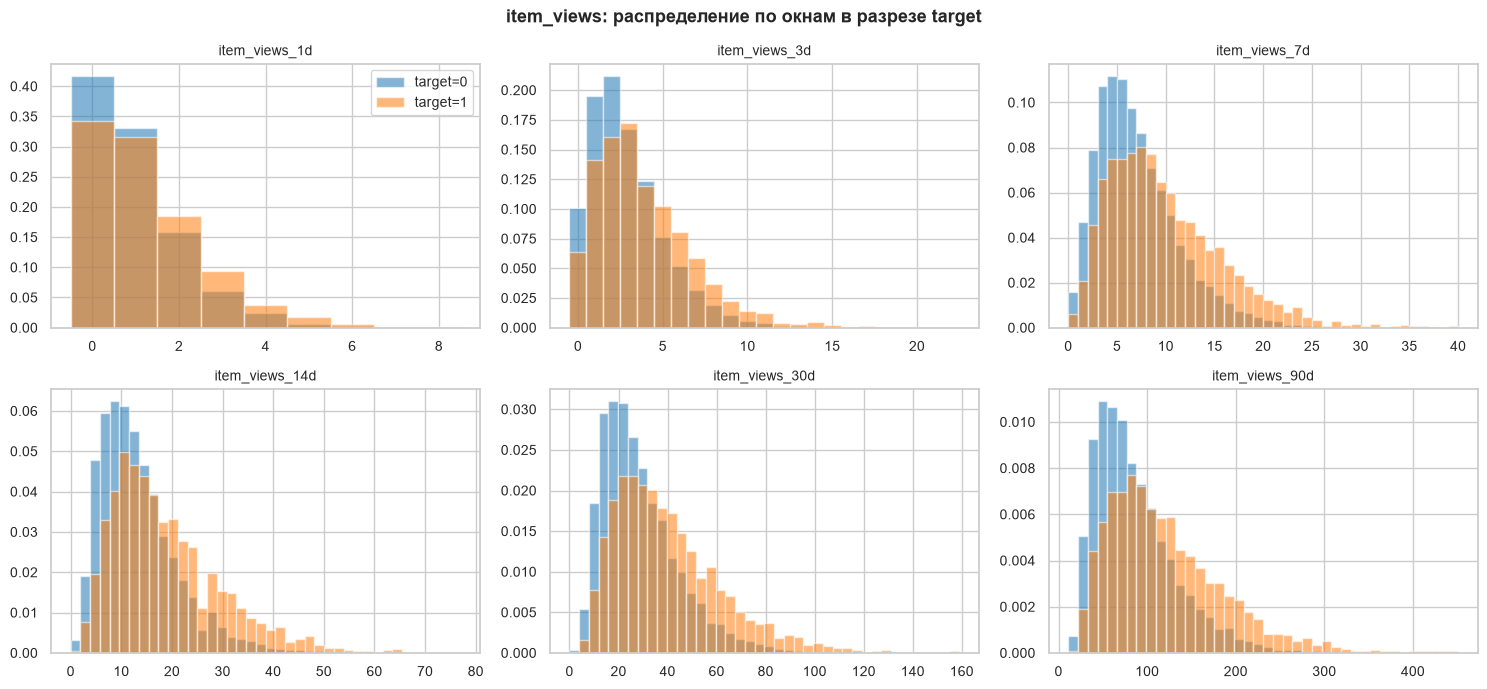

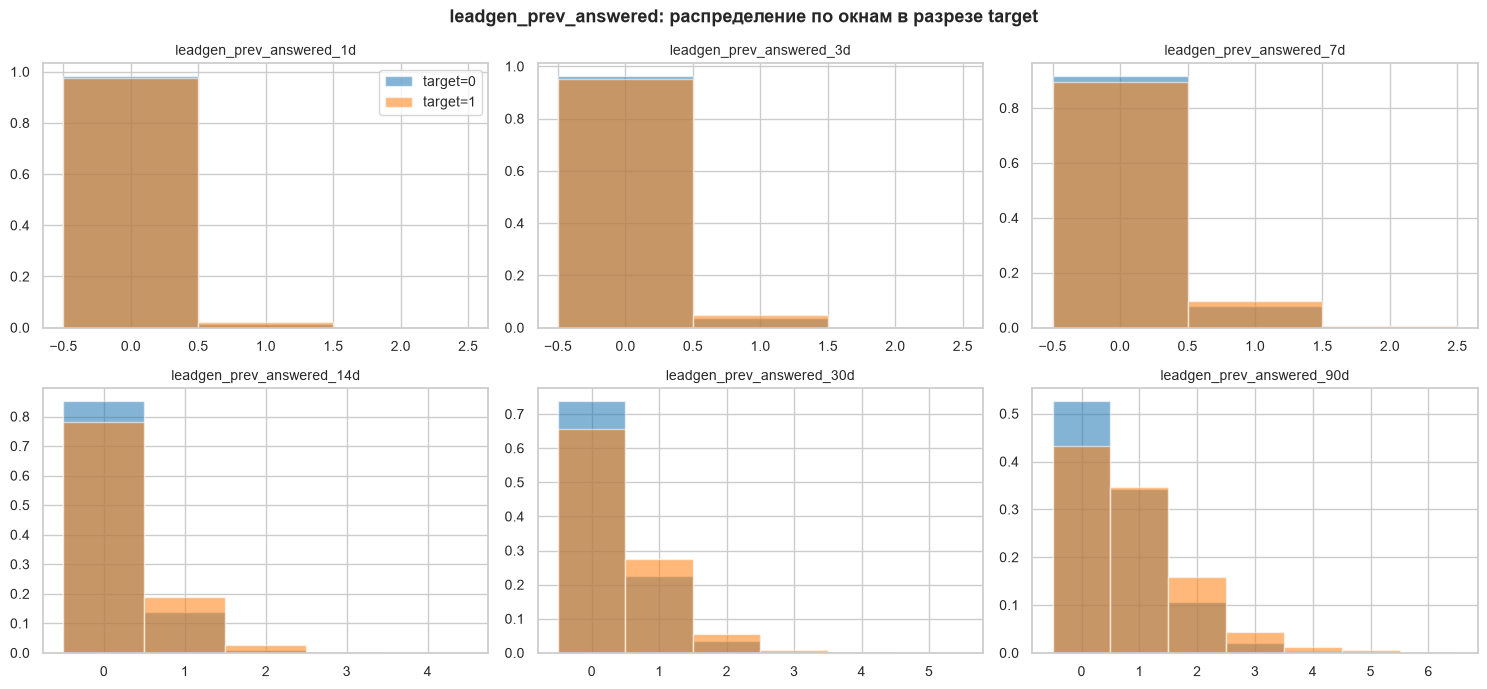

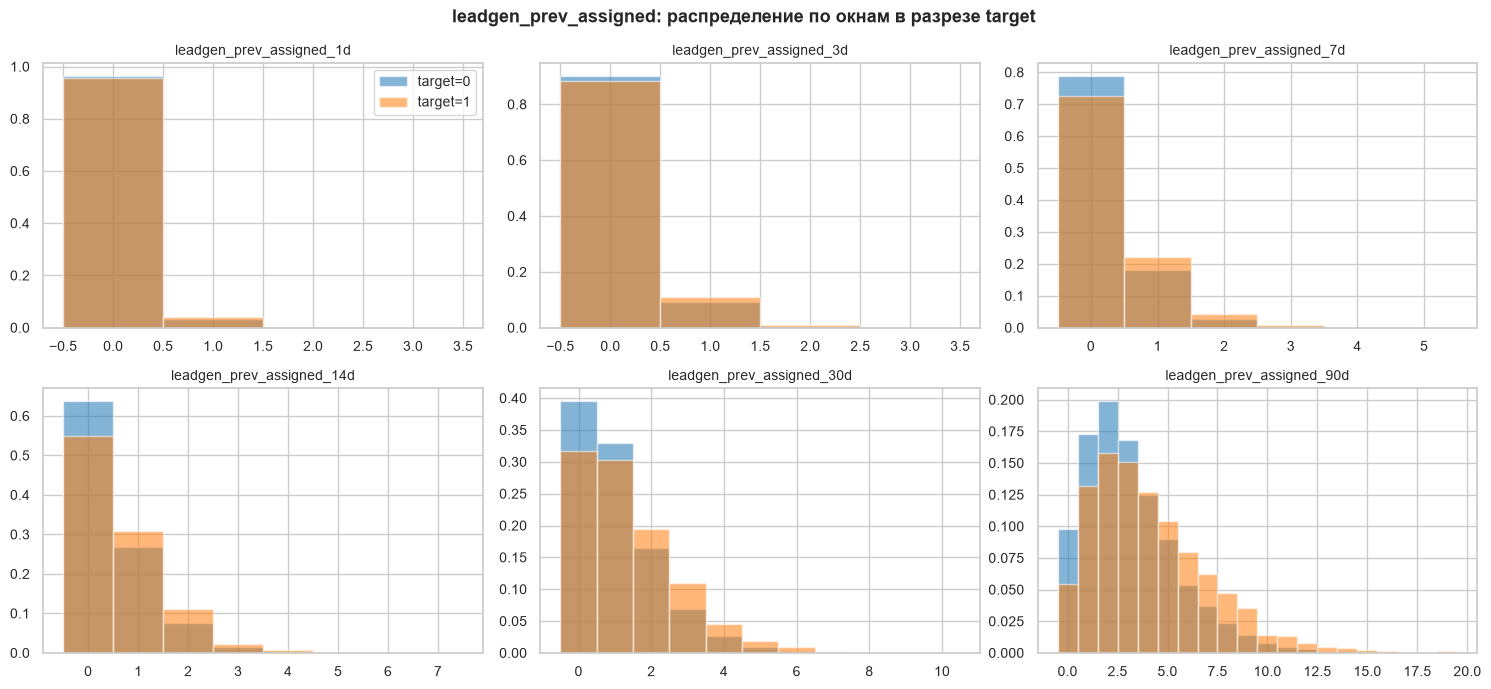

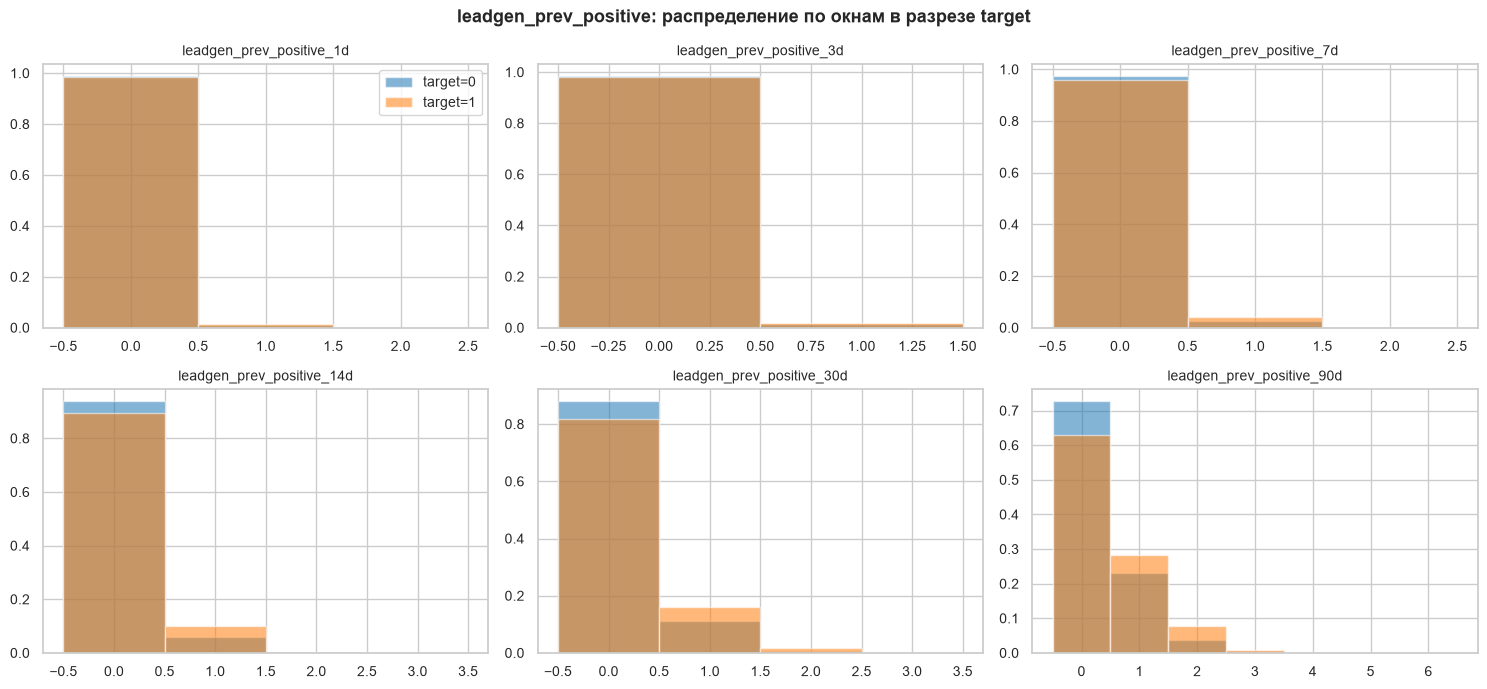

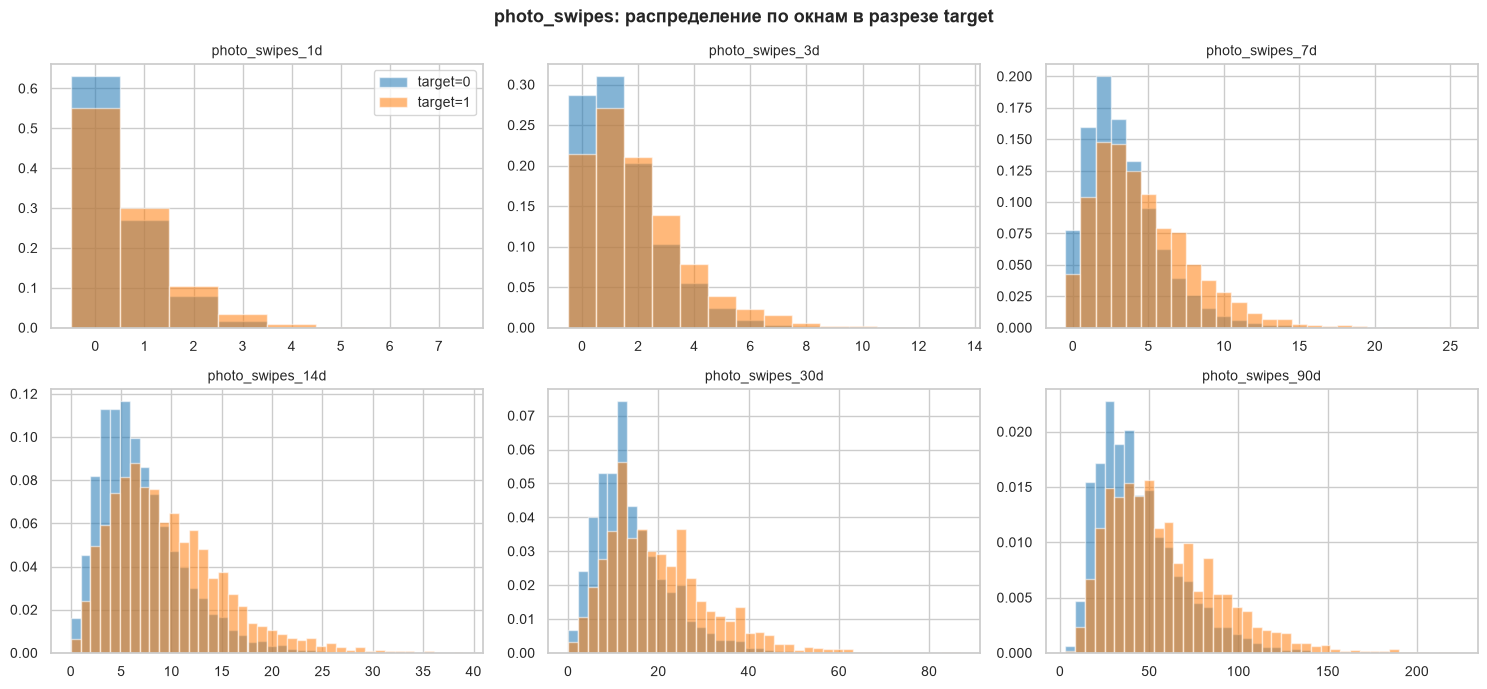

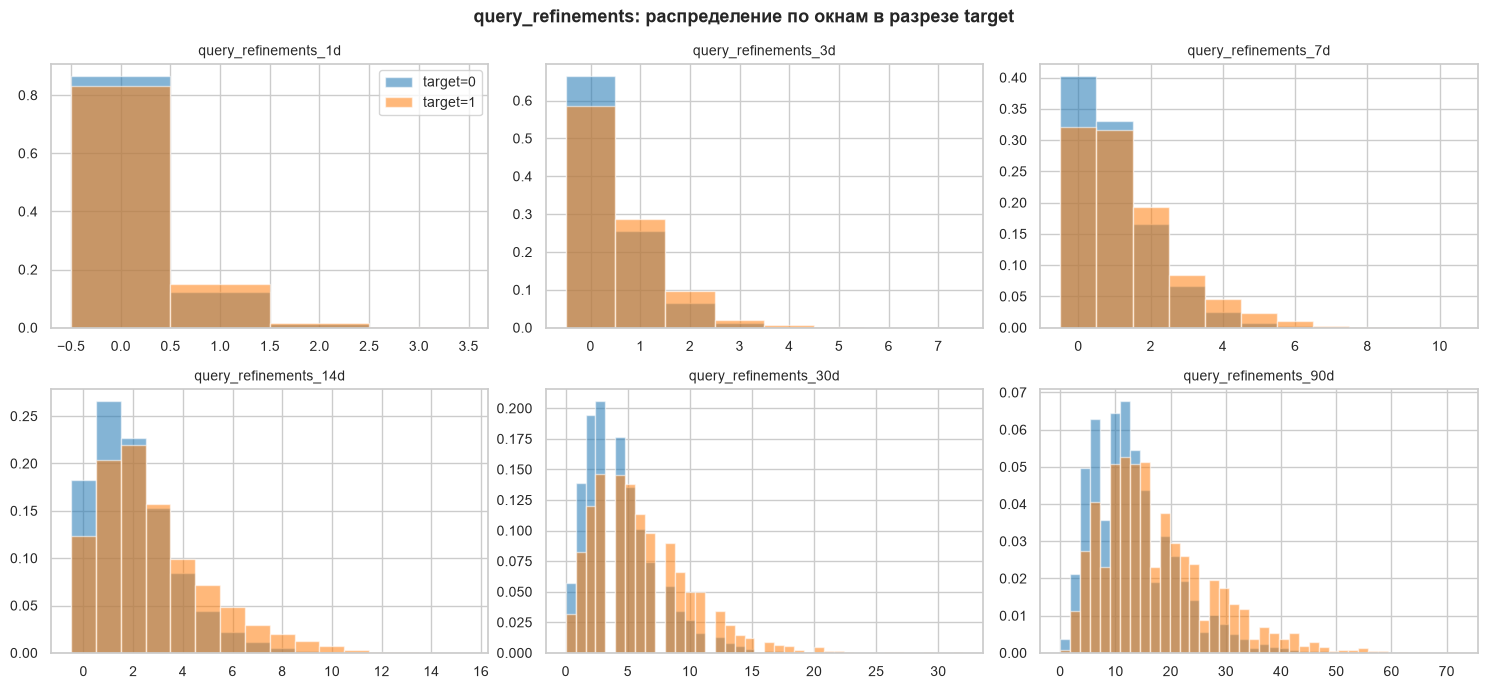

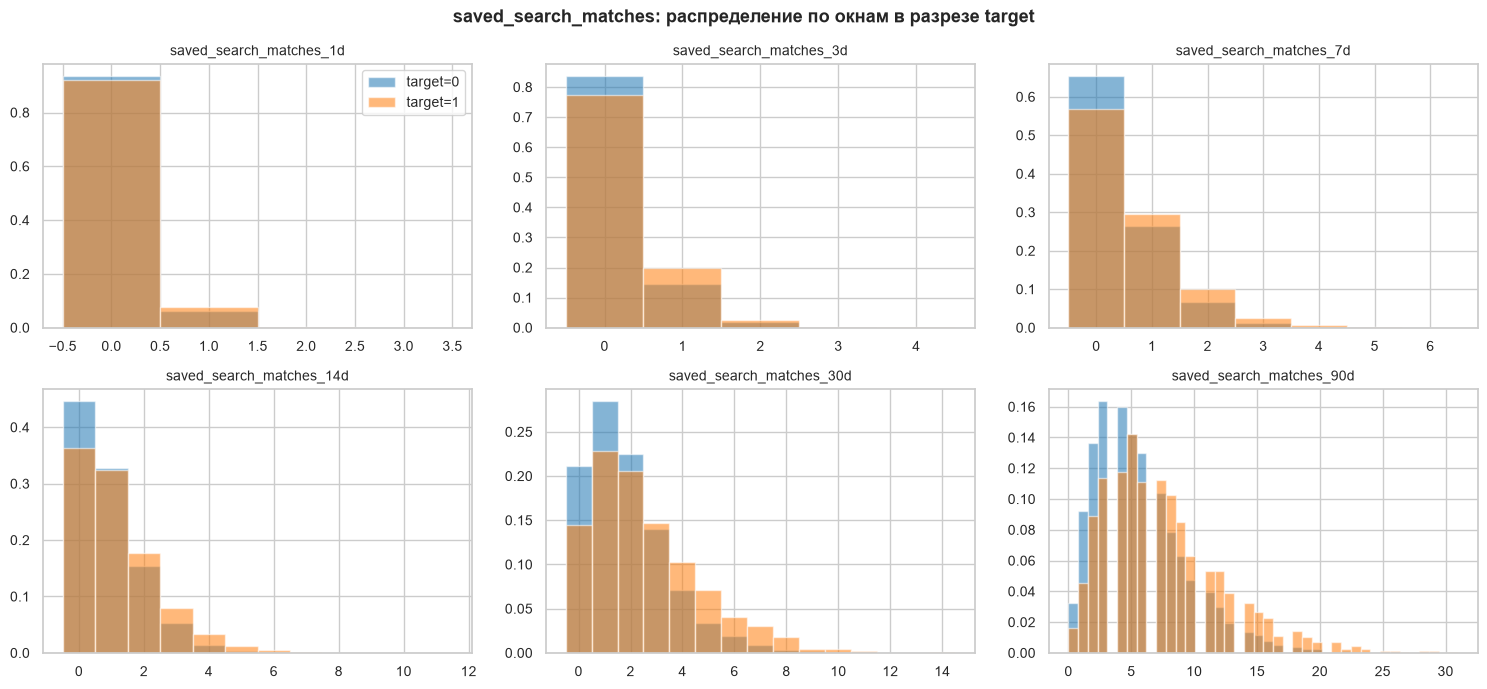

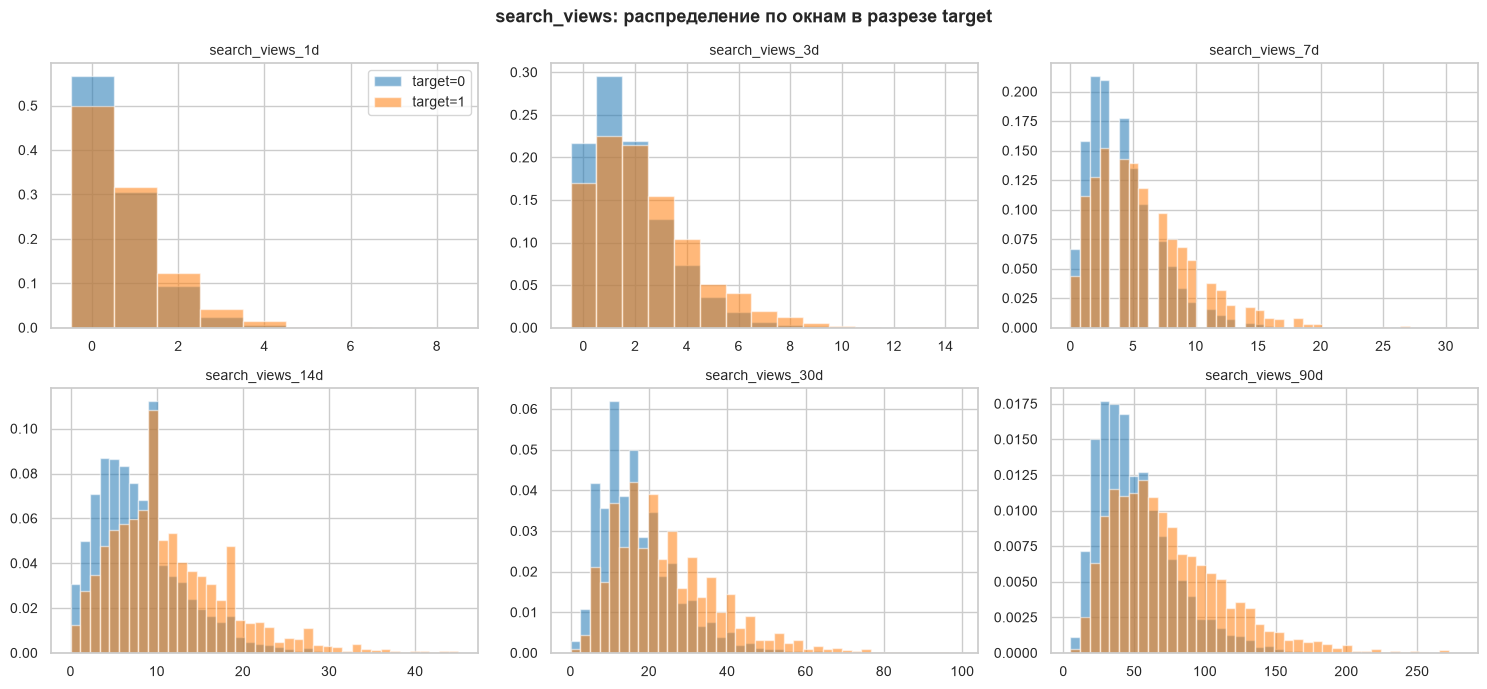

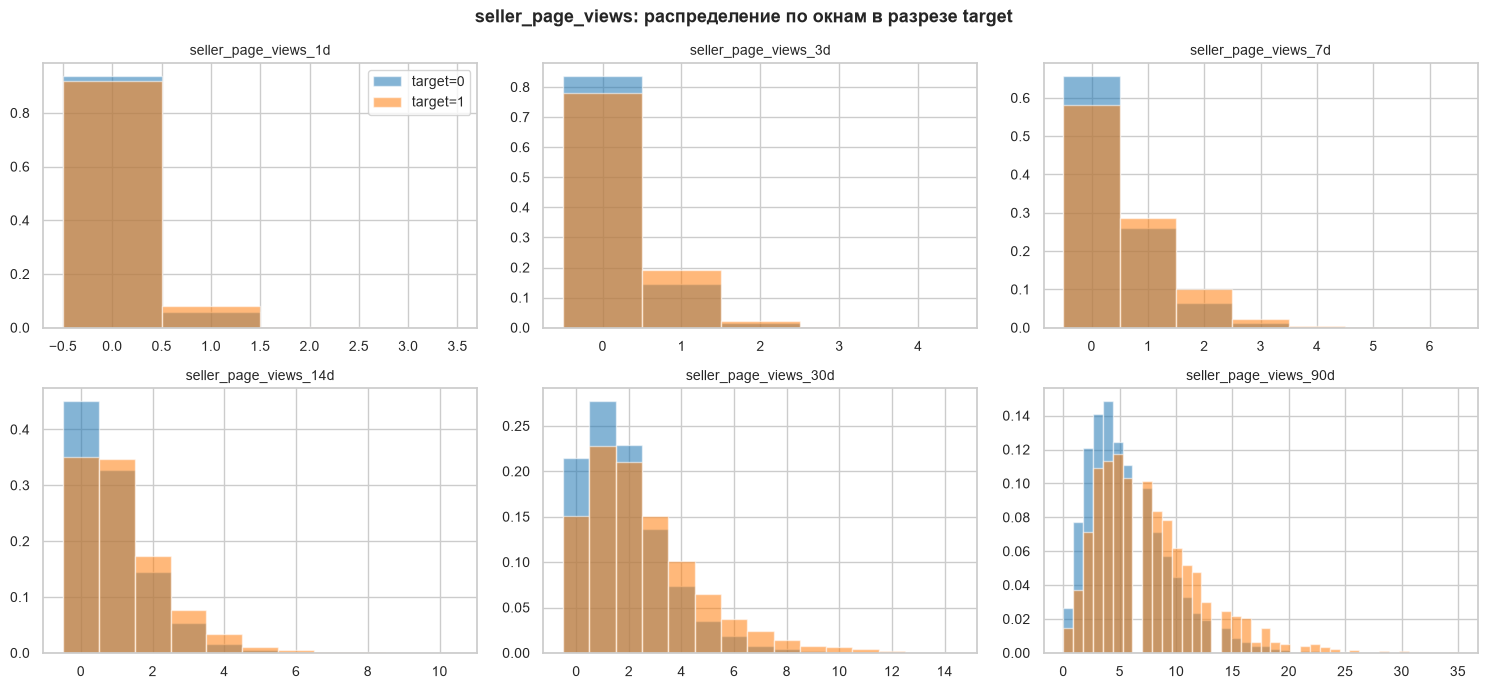

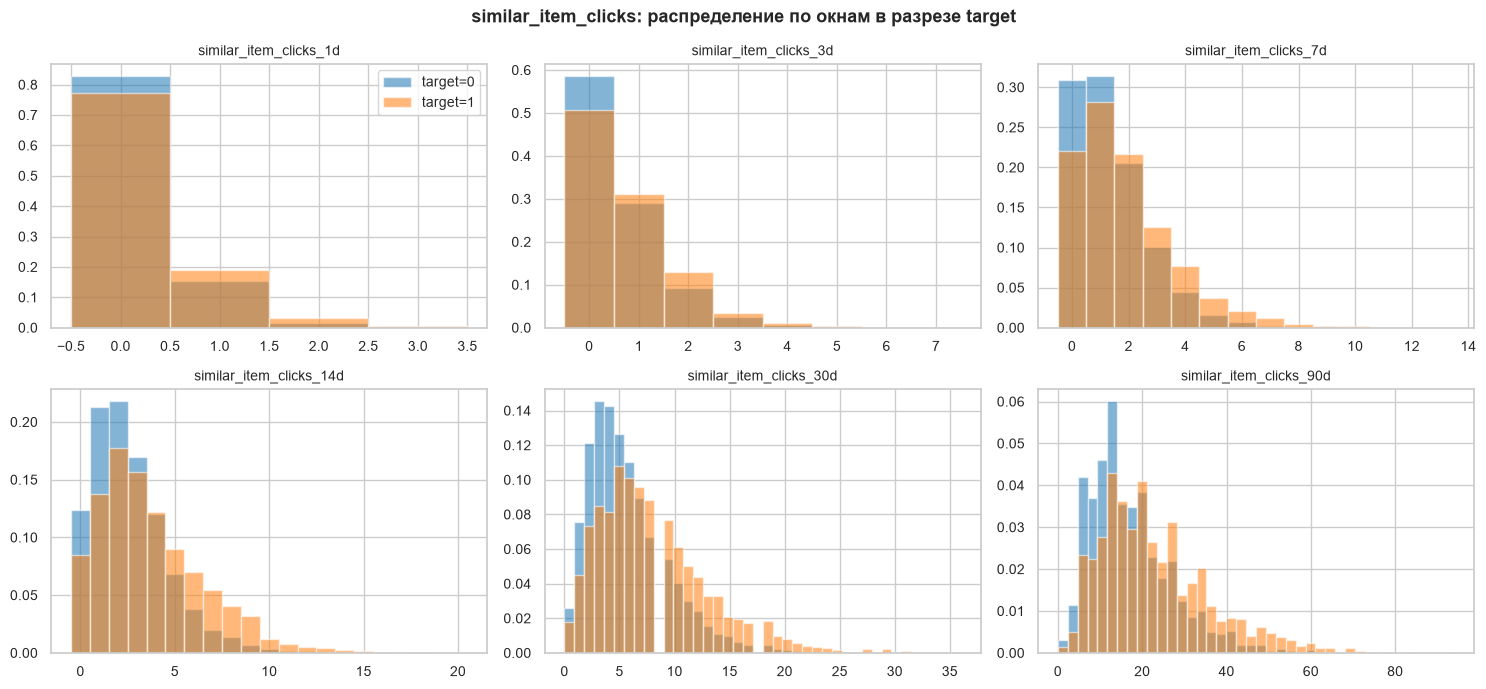

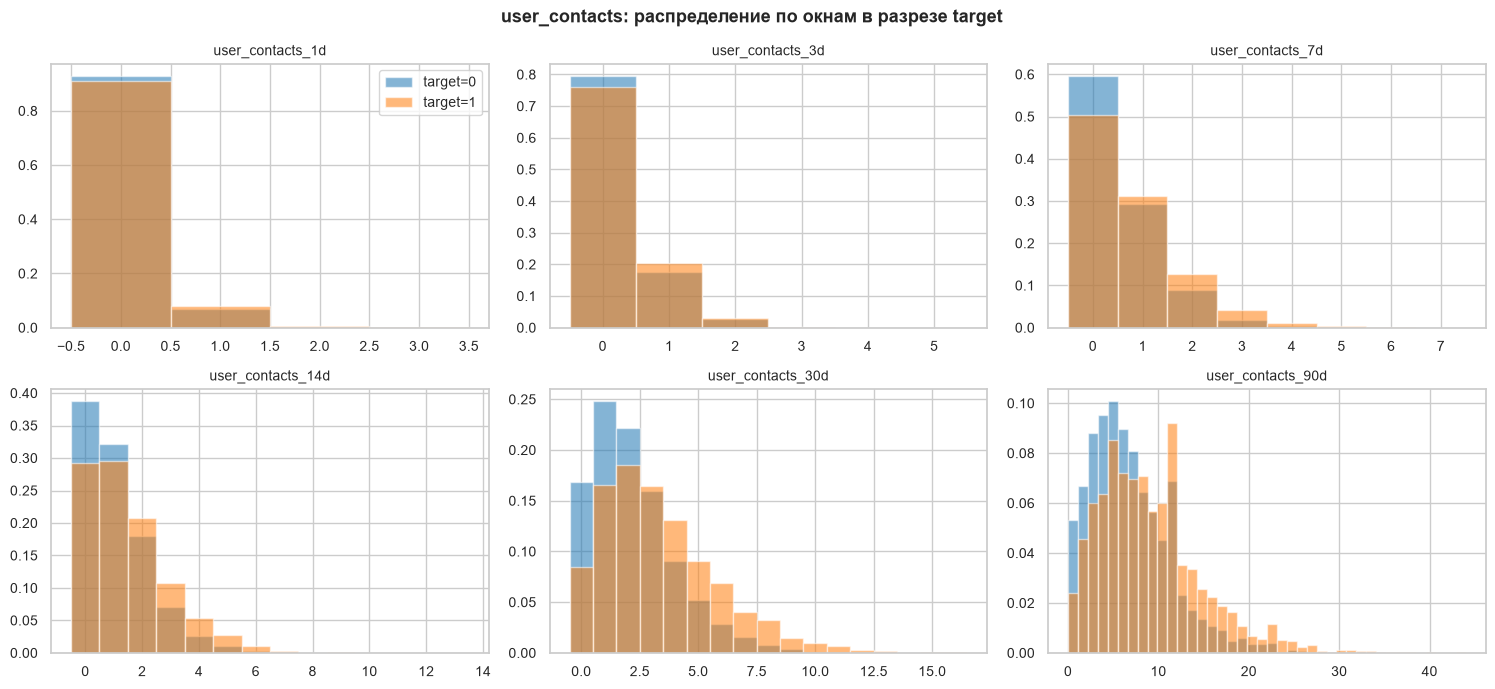

In [19]:
def plot_family_hist(df, family, windows=WINDOWS):
    """6 гистограмм семейства (по окнам) в разрезе target, сырые значения."""
    fig, axes = plt.subplots(2, 3, figsize=(15, 7))
    fig.suptitle(f"{family}: распределение по окнам в разрезе target",
                 fontsize=13, fontweight="bold")
    for ax, w in zip(axes.flat, windows):
        col = f"{family}_{w}"
        vals = df[col].dropna()
        if vals.max() <= 30:
            # дискретный признак: один столбик на каждое целое значение
            bins = np.arange(vals.max() + 2) - 0.5
        else:
            bins = np.histogram_bin_edges(vals, bins=40)
        for t, color in [(0, "tab:blue"), (1, "tab:orange")]:
            ax.hist(df.loc[df["target"] == t, col].dropna(), bins=bins,
                    alpha=0.55, density=True, color=color, label=f"target={t}")
        ax.set_title(col, fontsize=10)
    axes.flat[0].legend(frameon=True)
    fig.tight_layout()
    plt.show()

for fam in FAMILIES:
    plot_family_hist(train, fam)

In [20]:
corr_t = train[num_cols].corrwith(train.target)
display(corr_t.sort_values(ascending=False).head(15))
display(corr_t.sort_values().head(15))

search_views_90d           0.272307
item_views_90d             0.265135
item_views_30d             0.253351
search_views_30d           0.251135
item_views_14d             0.251023
photo_swipes_30d           0.249721
search_views_14d           0.241066
active_days_auto_90d       0.235906
user_active_days_30d       0.232126
item_favorites_90d         0.231042
item_views_7d              0.230012
user_contacts_30d          0.223430
similar_item_clicks_30d    0.222730
photo_swipes_14d           0.222492
query_refinements_30d      0.213181
dtype: float64

user_age_days              -0.011058
is_weekend                 -0.007704
mileage_km_log             -0.005475
car_age_years              -0.003500
assignment_weekday         -0.002126
seller_inventory_count      0.001914
seller_response_rate_30d    0.003124
item_price_log              0.004367
leadgen_prev_positive_3d    0.007774
assignment_hour             0.014276
leadgen_prev_positive_1d    0.015013
chat_opens_1d               0.017343
leadgen_prev_assigned_1d    0.017742
saved_search_matches_1d     0.023034
leadgen_prev_answered_1d    0.023831
dtype: float64

**Вывод**: сигнал размазан по десяткам признаков, максимальная корреляция с target ~0.27 (`search_views_90d`, `item_views_90d`). По линейной корреляции сильнее всего объем активности на длинных окнах (просмотры, поиск: 0.2–0.27) и контактные действия (`user_contacts_30d` 0.22). История прошлых лидов (`leadgen_prev_*`) выделяется в другом измерении: корреляция скромная (признак редкий), но относительный сдвиг максимальный — у успешных лидов истории в 1.5–1.7 раза больше (скрининг mean_1/mean_0). Гистограммы показывают: на окнах 1d–3d классы почти неразличимы, разделение нарастает с длиной окна. Статические атрибуты (возраст авто, пробег, цена, календарные) линейной связи с target не имеют (|corr| < 0.015).

### 3.4 Корреляционная структура признаков

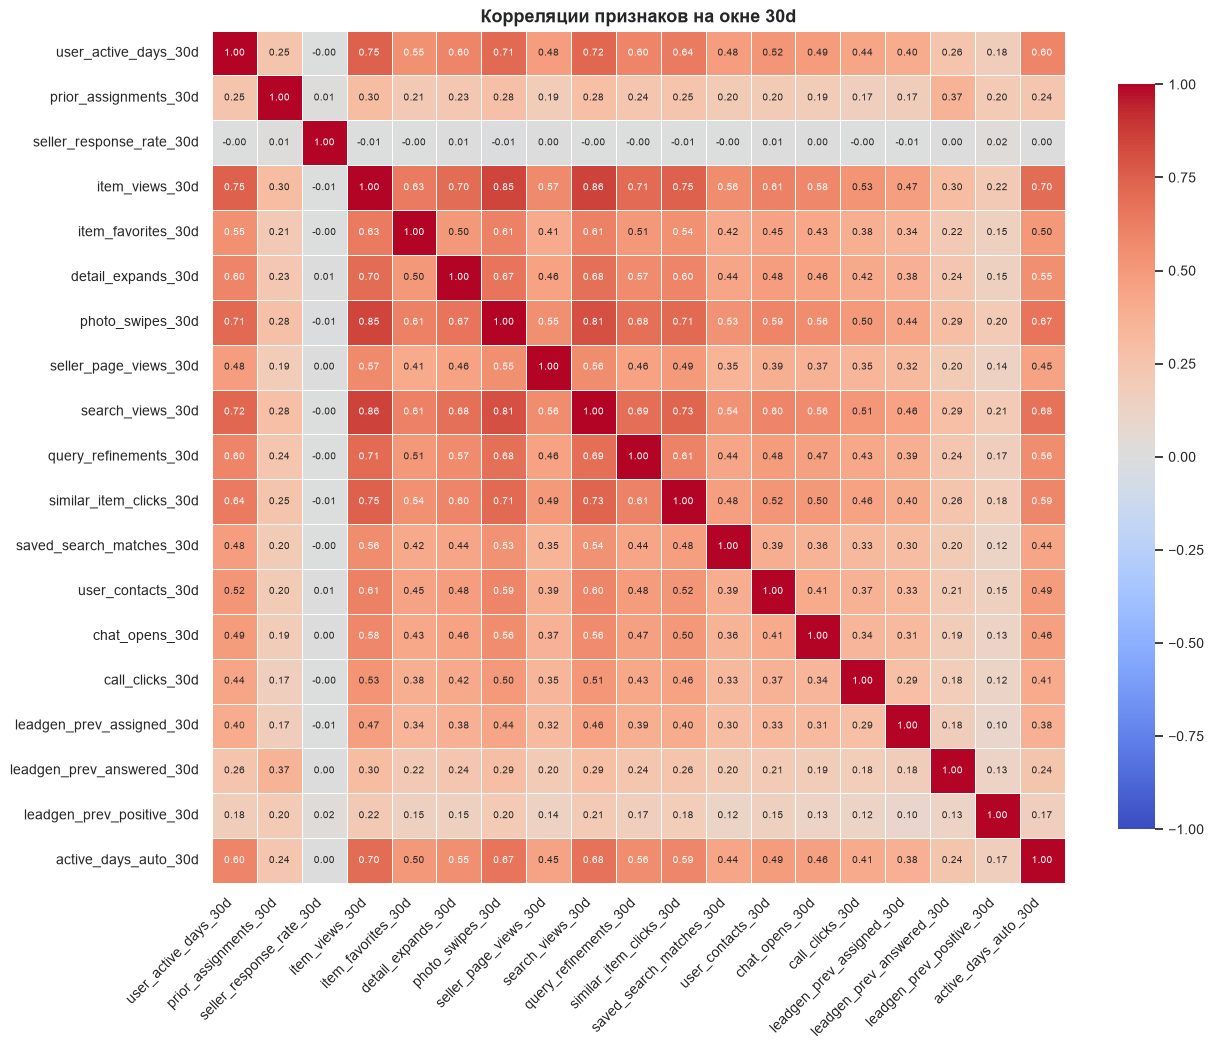

,corr_1d_3d,corr_3d_7d,corr_7d_14d,corr_14d_30d,corr_30d_90d
family,,,,,
item_views,0.33,0.56,0.73,0.84,0.91
search_views,0.24,0.45,0.64,0.77,0.88
photo_swipes,0.21,0.40,0.59,0.73,0.86
similar_item_clicks,0.11,0.21,0.36,0.53,0.73
query_refinements,0.07,0.17,0.30,0.47,0.68
detail_expands,0.06,0.16,0.29,0.44,0.66
active_days_auto,0.07,0.16,0.30,0.45,0.65
item_favorites,0.05,0.11,0.22,0.38,0.57
user_contacts,0.04,0.09,0.19,0.34,0.54


In [21]:
# Корреляции между признаками разных типов действий (окно 30d)
cols_30d = [c for c in num_cols if c.endswith("_30d")]
corr30 = train[cols_30d].corr()

plt.figure(figsize=(13, 11))
sns.heatmap(corr30, annot=True, fmt=".2f", annot_kws={"size": 7},
            cmap="coolwarm", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Корреляции признаков на окне 30d", fontsize=13, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Сводка корреляций между окнами внутри каждого семейства
ADJACENT = list(zip(WINDOWS[:-1], WINDOWS[1:]))   # [('1d','3d'), ('3d','7d'), ('7d','14d'), ('14d','30d'), ('30d','90d')]

rows = []
for fam in FAMILIES:
    corr = train[[f"{fam}_{w}" for w in WINDOWS]].corr()
    row = {"family": fam}
    for w1, w2 in ADJACENT:
        row[f"corr_{w1}_{w2}"] = round(corr.loc[f"{fam}_{w1}", f"{fam}_{w2}"], 2)
    rows.append(row)

fam_corr = pd.DataFrame(rows).set_index("family").sort_values("corr_30d_90d", ascending=False)
fam_corr

**Вывод**: "просмотровая" активность образует один сильно связанный блок (корреляции 0.5–0.86 между просмотрами, поиском, свайпами фото). Контактные действия связаны с ним умеренно (0.35–0.6) — частично отражают общую активность, частично собственное "намерение". Практически независимые источники сигнала — `seller_response_rate` (корреляция ~0 со всем) и история прошлых лидов `leadgen_prev_*` (0.1–0.4). Окна внутри семейств дублируются только у массовых действий (item_views 30d–90d: 0.91), у редких почти независимы (call_clicks: 0.43, leadgen_prev_positive: 0.15) — каждое окно несет свою информацию. Признаки не удаляем: деревья нечувствительны к мультиколлинеарности, отбор сделает CatBoost.

### 3.5 Аномалия seller_page_views: скрытый непрерывный сигнал

In [22]:
def audit_float_columns(df, name):
    """Ищет float-колонки, которые на самом деле bool или int"""
    result = {"bool_like": [], "int_like": [], "true_float": []}
    for col in df.select_dtypes("float"):
        vals = df[col].dropna()
        if vals.isin([0, 1]).all():
            result["bool_like"].append(col)
        elif (vals % 1 == 0).all():
            result["int_like"].append(col)
        else:
            result["true_float"].append(col)
    print(f"--- {name} ---")
    for k, v in result.items():
        print(f"{k}: {len(v)}", v[:8], "..." if len(v) > 8 else "")
    return result

audit_train = audit_float_columns(train, "train")
audit_test = audit_float_columns(test, "test")
audit_events = audit_float_columns(events, "events")

--- train ---
bool_like: 2 ['is_weekend', 'leadgen_prev_positive_3d'] 
int_like: 98 ['assignment_hour', 'assignment_weekday', 'user_active_days_30d', 'user_age_days', 'prior_assignments_30d', 'seller_inventory_count', 'item_views_1d', 'item_views_3d'] ...
true_float: 7 ['seller_response_rate_30d', 'item_price_log', 'car_age_years', 'mileage_km_log', 'seller_page_views_7d', 'seller_page_views_14d', 'seller_page_views_30d'] 
--- test ---
bool_like: 4 ['is_weekend', 'leadgen_prev_answered_1d', 'leadgen_prev_positive_1d', 'leadgen_prev_positive_3d'] 
int_like: 96 ['assignment_hour', 'assignment_weekday', 'user_active_days_30d', 'user_age_days', 'prior_assignments_30d', 'seller_inventory_count', 'item_views_1d', 'item_views_3d'] ...
true_float: 7 ['seller_response_rate_30d', 'item_price_log', 'car_age_years', 'mileage_km_log', 'seller_page_views_7d', 'seller_page_views_14d', 'seller_page_views_30d'] 
--- events ---
bool_like: 0 [] 
int_like: 1 ['src_slot'] 
true_float: 1 ['item_price_log'] 

In [23]:
# Число уникальных значений: подозрительные колонки в сравнении с другими признаками-счетчиками (seller_page_views_1d, item_views_30d)
for c in ["seller_page_views_7d", "seller_page_views_14d", "seller_page_views_30d",
          "seller_page_views_1d", "item_views_30d"]:
    print(c, train[c].nunique())

# Несет ли дробная часть сигнал: сравниваем конверсию строк с дробью и без
for c in FRAC_COLS:
    frac = train[c] % 1
    has_frac = frac > 0
    print(f"\n{c}: строк с дробью {has_frac.mean():.1%}")
    print("target rate: с дробью", round(train.loc[has_frac, 'target'].mean(), 3),
          "| без дроби", round(train.loc[~has_frac & train[c].notna(), 'target'].mean(), 3))

seller_page_views_7d 4759
seller_page_views_14d 7564
seller_page_views_30d 10596
seller_page_views_1d 4
item_views_30d 135

seller_page_views_7d: строк с дробью 34.7%
target rate: с дробью 0.243 | без дроби 0.189

seller_page_views_14d: строк с дробью 55.2%
target rate: с дробью 0.236 | без дроби 0.169

seller_page_views_30d: строк с дробью 77.4%
target rate: с дробью 0.22 | без дроби 0.155


**Вывод**: `seller_page_views_7d/14d/30d` — единственные счетчики с дробными значениями: 4.8–10.6 тыс. уникальных значений против 4 у `seller_page_views_1d` и ~135 у типичного счетчика (`item_views_30d`). Дробная часть связана с target: конверсия строк с дробью 0.243 против 0.189 без нее (7d), для 30d разрыв еще больше — 0.220 против 0.155.Интерпретируем как скрытую непрерывную интенсивность, зашитую в данные при генерации. Решение: колонки не округляем + выделяем дробную часть и флаг ее наличия в явные признаки (эффект проверяется экспериментами этапа 5).

### 3.6 События (events.csv)

In [24]:
# Привязываем к каждому событию момент назначения его лида
assign_ts = pd.concat([train[["lead_id", "assignment_ts"]],
                       test[["lead_id", "assignment_ts"]]])
ev = events.merge(assign_ts, on="lead_id", how="left")

# Доля событий ПОСЛЕ назначения — их нельзя использовать (утечка, см. вывод)
after = ev["event_ts"] >= ev["assignment_ts"]
print(f"событий после назначения: {after.mean():.1%} ({after.sum():,} из {len(ev):,})")

# Объем: событий на лид (только события до назначения)
valid = ev[~after]
per_lead = valid.groupby("lead_id").size()
print(f"\nсобытий на лид: медиана {per_lead.median():.0f}, "
      f"среднее {per_lead.mean():.1f}, максимум {per_lead.max()}")

# Покрытие: у скольких лидов есть хотя бы одно событие до назначения
all_leads = pd.concat([train["lead_id"], test["lead_id"]])
coverage = all_leads.isin(valid["lead_id"]).mean()
print(f"покрытие лидов валидными событиями: {coverage:.1%}")

# Структура: доли типов событий
print("\nдоли типов событий (валидные):")
print(valid["event_type"].value_counts(normalize=True).round(3))

# Глубина истории: сколько дней до назначения покрывают события
depth = (valid["assignment_ts"] - valid.groupby("lead_id")["event_ts"]
         .transform("min")).dt.days
print(f"\nглубина истории на лид: медиана {depth.median():.0f} дн., p90 {depth.quantile(0.9):.0f} дн.")

событий после назначения: 6.3% (16,124 из 254,705)

событий на лид: медиана 12, среднее 13.3, максимум 29
покрытие лидов валидными событиями: 99.9%

доли типов событий (валидные):
event_type
item_view     0.482
search        0.246
favorite      0.099
chat_open     0.092
call_click    0.080
Name: proportion, dtype: float64

глубина истории на лид: медиана 28 дн., p90 29 дн.


**Вывод**: 99.9% лидов покрыты событиями (медиана 12 событий на лид), глубина истории ~28–30 дней — признаки-окна из событий строим глубиной до месяца. 6.3% событий происходят ПОСЛЕ назначения — при построении признаков они отбрасываются фильтром `event_ts < assignment_ts`: эти события относятся к периоду, исход которого мы предсказываем, их использование — утечка. Доли типов событий (48% просмотров, 25% поиска, ~8–10% контактных действий) согласуются со структурой готовых агрегатов train.csv.

### 3.7 Пропуски и сдвиг train/test

In [25]:
na_pct = train.isna().mean().mul(100).round(2)
na_pct = na_pct[na_pct > 0].sort_values(ascending=False)
print(na_pct.head(25))
print(f"\nколонок с пропусками: {len(na_pct)}")

seller_response_rate_30d     5.17
leadgen_prev_positive_90d    3.30
item_favorites_3d            3.29
query_refinements_30d        3.26
detail_expands_3d            3.25
leadgen_prev_assigned_7d     3.18
user_contacts_3d             3.18
call_clicks_14d              3.17
call_clicks_30d              3.16
user_contacts_14d            3.16
saved_search_matches_30d     3.16
seller_page_views_30d        3.15
query_refinements_1d         3.15
similar_item_clicks_3d       3.15
call_clicks_3d               3.15
active_days_auto_30d         3.15
saved_search_matches_1d      3.15
seller_page_views_1d         3.13
leadgen_prev_answered_1d     3.11
seller_page_views_14d        3.10
detail_expands_30d           3.10
search_views_30d             3.10
item_favorites_7d            3.10
leadgen_prev_answered_90d    3.07
item_favorites_30d           3.07
dtype: float64

колонок с пропусками: 97


In [26]:
na_test = test.isna().mean().mul(100).round(2)
print(na_test[na_test > 0].sort_values(ascending=False).head(15))

seller_response_rate_30d    5.16
user_contacts_30d           3.55
saved_search_matches_1d     3.46
similar_item_clicks_30d     3.44
similar_item_clicks_7d      3.41
saved_search_matches_7d     3.37
search_views_30d            3.32
call_clicks_3d              3.30
leadgen_prev_assigned_3d    3.27
leadgen_prev_answered_3d    3.25
chat_opens_7d               3.23
chat_opens_1d               3.23
photo_swipes_30d            3.23
item_views_14d              3.23
item_views_7d               3.20
dtype: float64


In [27]:
# Системная проверка: z-статистика отличия конверсии строк с NaN по всем колонкам
rows = []
p_base = train[TARGET].mean()
for c in na_pct.index:
    m = train[c].isna()
    n1, n0 = m.sum(), (~m).sum()
    p1, p0 = train.loc[m, TARGET].mean(), train.loc[~m, TARGET].mean()
    se = np.sqrt(p_base * (1 - p_base) * (1 / n1 + 1 / n0))
    rows.append({"col": c, "rate_nan": round(p1, 3), "z": round((p1 - p0) / se, 2)})
zz = pd.DataFrame(rows).sort_values("z")
print(zz.head(5), "\n")
print(zz.tail(5), "\n")
print("доля колонок с |z| > 2:", round((zz["z"].abs() > 2).mean(), 3))

                         col  rate_nan     z
72         user_contacts_30d     0.142 -3.22
57  leadgen_prev_answered_3d     0.149 -2.97
84            item_views_14d     0.163 -2.17
86         user_contacts_90d     0.164 -2.13
75       active_days_auto_3d     0.168 -1.94 

                     col  rate_nan     z
9      user_contacts_14d     0.238  1.59
41  seller_page_views_3d     0.241  1.70
96      user_contacts_7d     0.244  1.70
64         item_views_1d     0.251  2.16
81         item_views_3d     0.255  2.35 

доля колонок с |z| > 2: 0.062


In [28]:
# Сдвиг распределений train vs test: доли категорий и медианы числовых

# Категориальные: сравнение долей
for c in CAT_COLS:
    tt = pd.concat({
        "train": train[c].value_counts(normalize=True),
        "test": test[c].value_counts(normalize=True),
    }, axis=1).round(3)
    tt["diff"] = (tt["test"] - tt["train"]).round(3)
    print(f"\n--- {c} ---\n", tt.sort_values("diff"))

# Числовые: сравнение медиан ключевых признаков
key_num = ["item_views_30d", "search_views_30d", "user_contacts_30d",
           "leadgen_prev_answered_30d", "user_age_days", "item_price_log"]
print("\nмедианы train vs test:")
print(pd.DataFrame({"train": train[key_num].median(),
                    "test": test[key_num].median()}).round(3))


--- lead_source ---
              train   test   diff
lead_source                     
CRM          0.353  0.339 -0.014
Model        0.415  0.419  0.004
Perf         0.231  0.243  0.012

--- call_center ---
              train   test   diff
call_center                     
voxys        0.424  0.416 -0.008
external     0.576  0.584  0.008

--- region ---
          train   test   diff
region                      
central  0.199  0.186 -0.013
south    0.197  0.186 -0.011
west     0.202  0.206  0.004
east     0.204  0.213  0.009
north    0.198  0.208  0.010

--- car_segment ---
              train   test   diff
car_segment                     
standard     0.422  0.417 -0.005
premium      0.139  0.138 -0.001
commercial   0.094  0.096  0.002
budget       0.344  0.349  0.005

--- lead_channel ---
               train   test   diff
lead_channel                     
web           0.257  0.246 -0.011
partner       0.247  0.247  0.000
retargeting   0.247  0.249  0.002
app           0.249  0.257

**Вывод**: пропуски случайны — равномерные ~3.1–3.3% во всех поведенческих агрегатах, одинаково в train и test. Системная проверка по всем 97 колонкам: доля колонок со значимым отличием конверсии строк с NaN (|z| > 2) составляет 6.2% при ожидаемых ~5% для случайных пропусков, отклонения в обе стороны — систематической связи пропусков с target нет. Оставляем NaN как есть (CatBoost обрабатывает нативно); заполнение нулем некорректно — смешало бы "нет данных" с "нет активности". Сдвига train/test нет: расхождения долей категорий ≤2.3 п.п., медианы числовых признаков совпадают.

## Этап 4. Сборка признаков

Собираем три набора признаков — эксперименты этапа 6 сравнивают их между собой:
1. `FEATURES_BASE` — готовые табличные признаки из train.csv / test.csv;
2. `FEATURES_FRAC` — + признаки из скрытого сигнала seller_page_views (раздел 3.5);
3. `FEATURES_FULL` — + признаки из сырых событий (раздел 3.6), построенные строго
   по событиям до момента назначения.

In [29]:
# Базовые признаки: все колонки, кроме идентификаторов, дат и target
base_cols = [c for c in train.columns if c not in NON_FEATURES]

# + признаки из скрытого сигнала seller_page_views
train_full = add_frac_features(train)
test_full = add_frac_features(test)
frac_cols = [c for c in train_full.columns if c.endswith(("_frac", "_has_frac"))]

# + признаки из событий (только события до назначения, фильтр внутри функции)
ev_feats = build_event_features(
    events,
    pd.concat([train[["lead_id", "assignment_ts", "item_price_log"]],
               test[["lead_id", "assignment_ts", "item_price_log"]]]),
)
event_cols = list(ev_feats.columns)

train_full = train_full.merge(ev_feats, left_on="lead_id", right_index=True, how="left")
test_full = test_full.merge(ev_feats, left_on="lead_id", right_index=True, how="left")

FEATURES_BASE = base_cols
FEATURES_FRAC = base_cols + frac_cols
FEATURES_FULL = base_cols + frac_cols + event_cols

print(f"базовых: {len(FEATURES_BASE)}, +frac: {len(FEATURES_FRAC)}, +events: {len(FEATURES_FULL)}")

базовых: 114, +frac: 120, +events: 153


## Этап 5. Протокол валидации

Тест — 5 последовательных дней строго после train, поэтому валидация имитирует
эту схему (случайный split завысил бы оценку — "подглядывал" бы в будущее):

- **Основной протокол — time-based holdout**: последние 4 дня train (19–22 апреля,
  ~3.4 тыс. лидов) откладываются под валидацию, модель обучается на первых 12 днях.
  Метрика — Daily AP по дням валидации, как на платформе.
- **Контрольный протокол — expanding window CV** (3 фолда: обучение растет
  7 → 10 → 13 дней, валидация — следующие 3 дня): применяется для проверки
  спорных решений, чтобы не переобучиться на единственный holdout.
- **Порог принятия изменений**: повторные прогоны одинаковой конфигурации дают
  разброс Daily AP ~±0.005, поэтому изменение принимается при приросте > 0.01
  на holdout, в серой зоне решает CV.

Замечание: у лидов последних дней train окно созревания target (5 дней) перекрывает
валидационный период. Это не утечка, а точное воспроизведение условий платформы —
train с готовыми target до 22.04 при тесте с 23.04 устроен так же.

In [30]:
train_part, valid_part = time_holdout(train_full, n_val_days=4)
print("обучение:", train_part.shape, "| валидация:", valid_part.shape)
print("дни валидации:", [str(d)[:10] for d in np.sort(valid_part["assignment_date"].unique())])

обучение: (10272, 158) | валидация: (3422, 158)
дни валидации: ['2026-04-19', '2026-04-20', '2026-04-21', '2026-04-22']


## Этап 6. Модели и эксперименты

Каждый эксперимент обучается на train_part и оценивается по Daily AP на valid_part
(протокол этапа 5). Результаты сведены в таблицу в конце этапа.

### 6.1 Baseline: логистическая регрессия
Отправная точка — модель из quickstart: медианная импутация + one-hot + LogReg
на базовых признаках.

In [31]:
num_features = [c for c in FEATURES_BASE if c not in CAT_COLS]

logreg = Pipeline([
    ("prep", ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc", StandardScaler())]), num_features),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("oh", OneHotEncoder(handle_unknown="ignore"))]), CAT_COLS),
    ])),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced",
                                 random_state=RANDOM_STATE)),
])

logreg.fit(train_part[FEATURES_BASE], train_part[TARGET])
val_scores = logreg.predict_proba(valid_part[FEATURES_BASE])[:, 1]

dap_logreg = daily_average_precision(valid_part[TARGET], val_scores,
                                     valid_part["assignment_date"])
print(f"Baseline LogReg | Daily AP: {dap_logreg:.5f}")

Baseline LogReg | Daily AP: 0.49073


### 6.2 CatBoost на базовых признаках

In [32]:
def run_experiment(cols, label):
    """Обучение CatBoost на наборе признаков cols, оценка Daily AP на holdout."""
    model = CatBoostClassifier(iterations=5000, learning_rate=0.01, depth=6,
                               loss_function="Logloss", eval_metric="PRAUC",
                               random_seed=RANDOM_STATE, early_stopping_rounds=200,
                               verbose=500)
    model.fit(Pool(train_part[cols], train_part[TARGET], cat_features=CAT_COLS),
              eval_set=Pool(valid_part[cols], valid_part[TARGET], cat_features=CAT_COLS))
    scores = model.predict_proba(valid_part[cols])[:, 1]
    dap = daily_average_precision(valid_part[TARGET], scores, valid_part["assignment_date"])
    print(f"{label}: Daily AP = {dap:.5f} (деревьев: {model.get_best_iteration()})")
    return model, dap

cb_base, dap_base = run_experiment(FEATURES_BASE, "CatBoost base")

0:	learn: 0.3441839	test: 0.3333171	best: 0.3333171 (0)	total: 67.9ms	remaining: 5m 39s
500:	learn: 0.5575391	test: 0.4613019	best: 0.4613019 (500)	total: 5.21s	remaining: 46.8s
1000:	learn: 0.6719994	test: 0.4990137	best: 0.4990422 (999)	total: 10.1s	remaining: 40.5s
1500:	learn: 0.7701484	test: 0.5247752	best: 0.5247752 (1500)	total: 14.4s	remaining: 33.5s
2000:	learn: 0.8411952	test: 0.5321580	best: 0.5321580 (2000)	total: 18.8s	remaining: 28.2s
2500:	learn: 0.8919376	test: 0.5380663	best: 0.5381280 (2498)	total: 23.4s	remaining: 23.3s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.5394453152
bestIteration = 2720

Shrink model to first 2721 iterations.
CatBoost base: Daily AP = 0.54565 (деревьев: 2720)


### 6.3 Скрытый сигнал: frac-признаки
Проверяем ценность дробной части seller_page_views (раздел 3.5) с двух сторон: сначала разрушаем сигнал округлением, затем усиливаем явными признаками.

In [33]:
# Контроль: округляем seller_page_views -> сигнал разрушен
train_part_r = train_part.copy()
valid_part_r = valid_part.copy()
train_part_r[FRAC_COLS] = train_part_r[FRAC_COLS].round(0)
valid_part_r[FRAC_COLS] = valid_part_r[FRAC_COLS].round(0)

model_r = CatBoostClassifier(iterations=5000, learning_rate=0.01, depth=6,
                             loss_function="Logloss", eval_metric="PRAUC",
                             random_seed=RANDOM_STATE, early_stopping_rounds=200, verbose=500)
model_r.fit(Pool(train_part_r[FEATURES_BASE], train_part_r[TARGET], cat_features=CAT_COLS),
            eval_set=Pool(valid_part_r[FEATURES_BASE], valid_part_r[TARGET], cat_features=CAT_COLS))
s_r = model_r.predict_proba(valid_part_r[FEATURES_BASE])[:, 1]
print("Daily AP с округленными seller_page_views:",
      round(daily_average_precision(valid_part_r[TARGET], s_r, valid_part_r["assignment_date"]), 5))

0:	learn: 0.3341265	test: 0.3175002	best: 0.3175002 (0)	total: 20ms	remaining: 1m 39s
500:	learn: 0.5247990	test: 0.4305794	best: 0.4308432 (495)	total: 4.77s	remaining: 42.9s
1000:	learn: 0.6382801	test: 0.4517546	best: 0.4517546 (1000)	total: 10.1s	remaining: 40.2s
1500:	learn: 0.7495782	test: 0.4634318	best: 0.4635505 (1498)	total: 14.9s	remaining: 34.9s
2000:	learn: 0.8294642	test: 0.4677127	best: 0.4677766 (1999)	total: 21s	remaining: 31.4s
2500:	learn: 0.8892983	test: 0.4714080	best: 0.4714191 (2499)	total: 28.8s	remaining: 28.8s
3000:	learn: 0.9296631	test: 0.4734573	best: 0.4735433 (2978)	total: 36.5s	remaining: 24.3s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.473680648
bestIteration = 3109

Shrink model to first 3110 iterations.
Daily AP с округленными seller_page_views: 0.47879


In [34]:
# Явные признаки дробной части
cb_frac, dap_frac = run_experiment(FEATURES_FRAC, "CatBoost + frac")

0:	learn: 0.3477937	test: 0.3028442	best: 0.3028442 (0)	total: 30.7ms	remaining: 2m 33s
500:	learn: 0.5916577	test: 0.5213523	best: 0.5213523 (500)	total: 10.4s	remaining: 1m 33s
1000:	learn: 0.6950531	test: 0.5437358	best: 0.5437358 (1000)	total: 14.9s	remaining: 59.6s
1500:	learn: 0.7790051	test: 0.5540186	best: 0.5540186 (1500)	total: 19.3s	remaining: 45s
2000:	learn: 0.8430783	test: 0.5581738	best: 0.5583710 (1905)	total: 24.2s	remaining: 36.3s
2500:	learn: 0.8907610	test: 0.5614467	best: 0.5616378 (2480)	total: 31s	remaining: 31s
3000:	learn: 0.9262478	test: 0.5620583	best: 0.5627479 (2886)	total: 38.8s	remaining: 25.8s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.5627478936
bestIteration = 2886

Shrink model to first 2887 iterations.
CatBoost + frac: Daily AP = 0.56877 (деревьев: 2886)


**Вывод**: округление seller_page_views роняет Daily AP с 0.5457 до 0.4788 (−6.7 п.п.) — дробная часть несет значимый обобщающийся сигнал. Явные frac-признаки поднимают качество до 0.5688 (+2.3 п.п. к базовой модели). Принято: используем FEATURES_FRAC.

### 6.4 Признаки-отношения

Гипотеза: отношения окон ("разгон интереса"), конверсии истории лидов и доля контактных действий в активности добавят сигнал поверх абсолютных значений.

In [35]:
DENSE_FAMILIES = ["item_views", "search_views", "photo_swipes"]
CONTACT_FAMILIES = ["user_contacts", "chat_opens", "call_clicks"]

def add_ratio_features(df):
    """12 инженерных признаков из готовых колонок.

    1) Отношения окон 7d/30d и 30d/90d для массовых действий (просмотры, поиск,
       свайпы фото): показывают динамику интереса - вырос он в последнюю неделю
       относительно месячного уровня или затухает. Для редких действий не строим:
       в знаменателе слишком часто нули.
    2) Доля успешных исходов в прошлых обращениях пользователя: сколько из ранее
       назначенных ему лидов он ответил (answered / assigned) и сколько завершились
       успехом (positive / assigned). По сути - личная конверсия пользователя.
    3) Отношение числа контактных действий (контакты, чаты, клики по звонку)
       к числу просмотров: отличает пользователя, готового связываться с продавцом,
       от того, кто просто листает объявления при том же объеме активности.

    Во всех знаменателях +1 - защита от деления на ноль.
    """
    df = df.copy()
    for fam in DENSE_FAMILIES:
        df[f"{fam}_r_7_30"] = df[f"{fam}_7d"] / (df[f"{fam}_30d"] + 1)
        df[f"{fam}_r_30_90"] = df[f"{fam}_30d"] / (df[f"{fam}_90d"] + 1)
    for w in ["30d", "90d"]:
        df[f"lg_answer_rate_{w}"] = (df[f"leadgen_prev_answered_{w}"]
                                     / (df[f"leadgen_prev_assigned_{w}"] + 1))
        df[f"lg_positive_rate_{w}"] = (df[f"leadgen_prev_positive_{w}"]
                                       / (df[f"leadgen_prev_assigned_{w}"] + 1))
        contacts = sum(df[f"{fam}_{w}"].fillna(0) for fam in CONTACT_FAMILIES)
        df[f"contact_share_{w}"] = contacts / (df[f"item_views_{w}"] + 1)
    return df

# Временно расширяем holdout-выборки ratio-признаками
train_part_ratio = add_ratio_features(train_part)
valid_part_ratio = add_ratio_features(valid_part)
ratio_cols = [c for c in train_part_ratio.columns if c not in train_part.columns]
FEATURES_RATIO = FEATURES_FRAC + ratio_cols
print(f"добавлено {len(ratio_cols)} признаков")

добавлено 12 признаков


In [36]:
# Эксперимент: frac-набор + ratio-признаки (сравнение с dap_frac = 0.5688)
model_ratio = CatBoostClassifier(iterations=5000, learning_rate=0.01, depth=6,
                                 loss_function="Logloss", eval_metric="PRAUC",
                                 random_seed=RANDOM_STATE, early_stopping_rounds=200, verbose=500)
model_ratio.fit(Pool(train_part_ratio[FEATURES_RATIO], train_part_ratio[TARGET], cat_features=CAT_COLS),
                eval_set=Pool(valid_part_ratio[FEATURES_RATIO], valid_part_ratio[TARGET], cat_features=CAT_COLS))
s_ratio = model_ratio.predict_proba(valid_part_ratio[FEATURES_RATIO])[:, 1]
dap_ratio = daily_average_precision(valid_part_ratio[TARGET], s_ratio, valid_part_ratio["assignment_date"])
print(f"CatBoost + frac + ratio: Daily AP = {dap_ratio:.5f}")

0:	learn: 0.3390038	test: 0.3232638	best: 0.3232638 (0)	total: 29.4ms	remaining: 2m 26s
500:	learn: 0.5977403	test: 0.5275304	best: 0.5276308 (494)	total: 9.01s	remaining: 1m 20s
1000:	learn: 0.6923231	test: 0.5458579	best: 0.5458579 (1000)	total: 15.4s	remaining: 1m 1s
1500:	learn: 0.7800331	test: 0.5562054	best: 0.5565040 (1480)	total: 22.6s	remaining: 52.6s
2000:	learn: 0.8487572	test: 0.5609650	best: 0.5612708 (1971)	total: 30.4s	remaining: 45.6s
2500:	learn: 0.9017809	test: 0.5636324	best: 0.5638276 (2487)	total: 38.5s	remaining: 38.5s
3000:	learn: 0.9358457	test: 0.5646258	best: 0.5650547 (2920)	total: 47.2s	remaining: 31.4s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.5650546656
bestIteration = 2920

Shrink model to first 2921 iterations.
CatBoost + frac + ratio: Daily AP = 0.56877


In [37]:
# Прирост в серой зоне -> контроль на expanding CV
cv_ratio = run_cv(add_ratio_features(train_full), FEATURES_RATIO, CAT_COLS, label="ratio")
cv_frac_ref = run_cv(train_full, FEATURES_FRAC, CAT_COLS, label="frac ")

ratio fold 1: 0.49429 (val: 2026-04-14—2026-04-16)
ratio fold 2: 0.55075 (val: 2026-04-17—2026-04-19)
ratio fold 3: 0.56481 (val: 2026-04-20—2026-04-22)
ratio mean: 0.53662 ± 0.03048

frac  fold 1: 0.50716 (val: 2026-04-14—2026-04-16)
frac  fold 2: 0.53349 (val: 2026-04-17—2026-04-19)
frac  fold 3: 0.57050 (val: 2026-04-20—2026-04-22)
frac  mean: 0.53705 ± 0.02598



**Вывод**: holdout 0.5688 против 0.5688 — прирост отсутствует; expanding CV: 0.5366 против 0.5370 — тоже ноль. CatBoost аппроксимирует такие отношения последовательными сплитами самостоятельно. **Отклонено**, ratio-признаки в финальный набор не входят.

### 6.6 Признаки из событий
Главная гипотеза решения: сырые события до момента назначения содержат сигнал, которого нет в готовых агрегатах (давность действий, разнообразие контекстов, ценовой профиль интереса).

In [38]:
cb_full, dap_full = run_experiment(FEATURES_FULL, "CatBoost + frac + events")

0:	learn: 0.4974182	test: 0.4987167	best: 0.4987167 (0)	total: 14.3ms	remaining: 1m 11s
500:	learn: 0.6984685	test: 0.6597797	best: 0.6598338 (499)	total: 7.67s	remaining: 1m 8s
1000:	learn: 0.7719818	test: 0.6816955	best: 0.6817885 (999)	total: 14.4s	remaining: 57.5s
1500:	learn: 0.8425484	test: 0.6900076	best: 0.6900354 (1499)	total: 21.4s	remaining: 49.9s
2000:	learn: 0.8981208	test: 0.6931602	best: 0.6932689 (1984)	total: 28.5s	remaining: 42.8s
2500:	learn: 0.9370535	test: 0.6961315	best: 0.6961777 (2498)	total: 35.6s	remaining: 35.6s
3000:	learn: 0.9629128	test: 0.6974633	best: 0.6975400 (2956)	total: 42s	remaining: 28s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.6980242728
bestIteration = 3050

Shrink model to first 3051 iterations.
CatBoost + frac + events: Daily AP = 0.70123 (деревьев: 3050)


In [39]:
# Проверки против утечки: давность событий не может быть отрицательной,
# и качество только на event-признаках (санити-чек масштаба вклада)
rec_cols = [c for c in event_cols if "hours_since" in c or c == "ev_history_depth_h"]
assert (ev_feats[rec_cols].dropna() >= 0).all().all(), "события после назначения!"

# Топ признаков финальной модели
fi = pd.DataFrame({
    "feature": FEATURES_FULL,
    "importance": cb_full.get_feature_importance(
        Pool(train_part[FEATURES_FULL], train_part[TARGET], cat_features=CAT_COLS)),
}).sort_values("importance", ascending=False)
display(fi.head(15))

,feature,importance
150,ev_n_ctx,5.545167
152,ev_price_std,5.236765
118,seller_page_views_30d_frac,4.477614
116,seller_page_views_14d_frac,3.270026
122,ev_favorite_3d,3.104954
114,seller_page_views_7d_frac,2.535710
0,lead_source,2.159384
45,seller_page_views_14d,1.950307
46,seller_page_views_30d,1.920610
146,ev_hours_since_any,1.862292


In [40]:
# Иллюстрация сильнейшего event-признака: конверсия по разнообразию контекстов
print(train_full.groupby("ev_n_ctx", dropna=True)[TARGET].agg(["mean", "count"]))

              mean  count
ev_n_ctx                 
1.0       0.105263     95
2.0       0.084746    354
3.0       0.100215   1397
4.0       0.140786   3587
5.0       0.200887   7213
6.0       0.660981    938
7.0       0.965909     88
8.0       1.000000      2


**Вывод**: признаки из событий дают крупнейший прирост решения — Daily AP 0.7012 против 0.5688 (+13.2 п.п.). Проверка на утечку пройдена: давность всех событий неотрицательна, признаки построены строго по событиям до назначения. В топе
importance — event-признаки и frac-признаки: разнообразие контекстов показа (`ev_n_ctx`, 5.5% importance) — конверсия монотонно растет с 0.10 при 1–2 контекстах до 0.66 при 6 и 0.97+ при 7–8; разброс цен просмотренного (`ev_price_std`); давность последней активности (`ev_hours_since_any`). Поведенческая интерпретация: лид "горячее", если пользователь недавно активен, смотрит объявления из многих контекстов и в широком ценовом диапазоне.

**Принято**: финальный набор — FEATURES_FULL.

### 6.7 Подтверждение на expanding CV

In [41]:
cv_full = run_cv(train_full, FEATURES_FULL, CAT_COLS, label="full ")

full  fold 1: 0.64956 (val: 2026-04-14—2026-04-16)
full  fold 2: 0.69680 (val: 2026-04-17—2026-04-19)
full  fold 3: 0.69542 (val: 2026-04-20—2026-04-22)
full  mean: 0.68059 ± 0.02195



**Вывод**: прирост event-признаков подтвержден во всех фолдах expanding CV: 0.650 / 0.697 / 0.695, mean 0.681 ± 0.022 против 0.537 у FEATURES_FRAC (+14 п.п.). Улучшение не является артефактом одного holdout. Дополнительно виден рост качества с объемом обучающих данных (фолд 1 → 3: обучение 7 → 13 дней) — финальное обучение на полных 16 днях train должно дать на тесте не хуже holdout-оценки.

### 6.8 Расширенные признаки событий (v2)

Развиваем то, что сработало в первой версии: `ev_n_ctx` (разнообразие контекстов показа) — сильнейший признак модели, поэтому строим его оконные версии; добавляем плотность активности (интервалы между событиями), смещение ценового интереса и счетчики по отдельным контекстам. Гипотеза: недавнее поведение и структура контекстов содержат сигнал сверх суммарных счетчиков v1.

In [42]:
def build_event_features_v2(events, base_df):
    """Вторая волна признаков из событий (по событиям строго до назначения).

    Для каждого лида считаем:
    1) Разнообразие НЕДАВНЕЙ активности: сколько разных контекстов показа
       (ctx_seq) и слотов (src_slot) встречается в событиях за последние
       7 и 30 дней. Общее разнообразие за всю историю (ev_n_ctx) - самый
       сильный признак модели v1; проверяем его оконные версии.
    2) Плотность активности: средний интервал между событиями за всю историю
       и последний интервал. Если последний заметно короче среднего -
       события учащаются, пользователь "разогревается" перед назначением.
    3) Смещение ценового интереса: средняя цена просмотренного за последние
       7 дней минус средняя за всю историю. Больше нуля - пользователь стал
       смотреть машины дороже, меньше - дешевле.
    4) Число событий в каждом из 8 контекстов показа (ev_ctx_c01..c08) -
       проверяем, не информативнее ли отдельные контексты, чем их сумма.
    """
    ev = events.merge(base_df[["lead_id", "assignment_ts"]], on="lead_id", how="inner")
    ev = ev[ev["event_ts"] < ev["assignment_ts"]].copy()
    ev["hours_before"] = (ev["assignment_ts"] - ev["event_ts"]).dt.total_seconds() / 3600

    g = ev.groupby("lead_id")
    feats = pd.DataFrame(index=g.size().index)

    # 1. Сколько разных контекстов и слотов в событиях лида за последние 7/30 дней
    for w, days in [("7d", 7), ("30d", 30)]:
        gw = ev[ev["hours_before"] <= days * 24].groupby("lead_id")
        feats[f"ev_n_ctx_{w}"] = gw["ctx_seq"].nunique()
        feats[f"ev_n_slots_{w}"] = gw["src_slot"].nunique()

    # 2. Интервалы между соседними событиями лида (в часах):
    ev_sorted = ev.sort_values(["lead_id", "event_ts"])
    ev_sorted["gap_h"] = ev_sorted.groupby("lead_id")["event_ts"].diff().dt.total_seconds() / 3600
    feats["ev_gap_mean_h"] = ev_sorted.groupby("lead_id")["gap_h"].mean()
    feats["ev_gap_last_h"] = ev_sorted.groupby("lead_id")["gap_h"].last()

    # 3. Средняя цена просмотренного за последние 7 дней минус средняя за всю историю
    last7 = ev[ev["hours_before"] <= 7 * 24].groupby("lead_id")["item_price_log"].mean()
    feats["ev_price_shift_7d"] = last7 - g["item_price_log"].mean()

    # 4. Число событий лида в каждом из 8 контекстов показа
    ctx = ev.pivot_table(index="lead_id", columns="ctx_seq", aggfunc="size", fill_value=0)
    ctx.columns = [f"ev_ctx_{c}" for c in ctx.columns]
    feats = feats.join(ctx)
    return feats

ev_feats_v2 = build_event_features_v2(
    events, pd.concat([train[["lead_id", "assignment_ts"]], test[["lead_id", "assignment_ts"]]]))
print("v2-признаков:", ev_feats_v2.shape)

v2-признаков: (17977, 15)


In [43]:
# Эксперимент: FEATURES_FULL + v2 (сравнение с прошлой версией = 0.7012)
train_v2 = train_full.merge(ev_feats_v2, left_on="lead_id", right_index=True, how="left")
test_v2 = test_full.merge(ev_feats_v2, left_on="lead_id", right_index=True, how="left")
event_cols_v2 = list(ev_feats_v2.columns)
FEATURES_V2 = FEATURES_FULL + event_cols_v2

tr2, va2 = time_holdout(train_v2, n_val_days=4)
model_v2 = CatBoostClassifier(iterations=10000, learning_rate=0.01, depth=6,
                              loss_function="Logloss", eval_metric="PRAUC",
                              random_seed=RANDOM_STATE, early_stopping_rounds=200, verbose=1000)
model_v2.fit(Pool(tr2[FEATURES_V2], tr2[TARGET], cat_features=CAT_COLS),
             eval_set=Pool(va2[FEATURES_V2], va2[TARGET], cat_features=CAT_COLS))
s_v2 = model_v2.predict_proba(va2[FEATURES_V2])[:, 1]
dap_v2 = daily_average_precision(va2[TARGET], s_v2, va2["assignment_date"])
print(f"CatBoost + events v2: Daily AP = {dap_v2:.5f}")

0:	learn: 0.4695172	test: 0.4570517	best: 0.4570517 (0)	total: 25.4ms	remaining: 4m 13s
1000:	learn: 0.7873852	test: 0.7029908	best: 0.7029908 (1000)	total: 13.6s	remaining: 2m 2s
2000:	learn: 0.9068571	test: 0.7145744	best: 0.7147025 (1995)	total: 26.3s	remaining: 1m 45s
3000:	learn: 0.9667744	test: 0.7190890	best: 0.7191638 (2992)	total: 39.1s	remaining: 1m 31s
4000:	learn: 0.9903195	test: 0.7222386	best: 0.7223284 (3990)	total: 53.2s	remaining: 1m 19s
5000:	learn: 0.9978663	test: 0.7244882	best: 0.7245876 (4981)	total: 1m 10s	remaining: 1m 10s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.7245876117
bestIteration = 4981

Shrink model to first 4982 iterations.
CatBoost + events v2: Daily AP = 0.72869


In [44]:
# Какие из новых признаков реально используются моделью
fi_v2 = pd.DataFrame({
    "feature": FEATURES_V2,
    "importance": model_v2.get_feature_importance(
        Pool(tr2[FEATURES_V2], tr2[TARGET], cat_features=CAT_COLS)),
}).sort_values("importance", ascending=False)

display(fi_v2.head(15))                                     # общий топ модели
display(fi_v2[fi_v2["feature"].isin(event_cols_v2)])        # вклад именно v2-признаков

,feature,importance
152,ev_price_std,4.078356
118,seller_page_views_30d_frac,3.852163
162,ev_ctx_c03,2.751195
116,seller_page_views_14d_frac,2.715450
122,ev_favorite_3d,2.339530
114,seller_page_views_7d_frac,1.973417
0,lead_source,1.877027
45,seller_page_views_14d,1.725819
46,seller_page_views_30d,1.699907
146,ev_hours_since_any,1.630856


,feature,importance
162,ev_ctx_c03,2.751195
166,ev_ctx_c07,1.585918
158,ev_gap_last_h,1.431081
159,ev_price_shift_7d,1.355020
164,ev_ctx_c05,1.310003
155,ev_n_ctx_30d,1.076920
157,ev_gap_mean_h,0.840901
163,ev_ctx_c04,0.396835
165,ev_ctx_c06,0.372241
161,ev_ctx_c02,0.242379


In [45]:
cv_v2 = run_cv(train_v2, FEATURES_V2, CAT_COLS, label="v2   ")
# референс: cv_full mean 0.6806 (раздел 6.7)

v2    fold 1: 0.67937 (val: 2026-04-14—2026-04-16)
v2    fold 2: 0.71499 (val: 2026-04-17—2026-04-19)
v2    fold 3: 0.72277 (val: 2026-04-20—2026-04-22)
v2    mean: 0.70571 ± 0.01889



**Вывод**: v2-признаки дают Daily AP 0.7287 против 0.7012 (+2.7 п.п.), прирост подтвержден во всех фолдах expanding CV (mean 0.7057 против 0.6806). Наибольший вклад — счетчики по отдельным контекстам показа (`ev_ctx_c03`, `ev_ctx_c07`,
`ev_ctx_c05`): контексты оказались неравноценны, и разбивка информативнее общей суммы. Также работают последний интервал между событиями (`ev_gap_last_h`) и смещение ценового интереса (`ev_price_shift_7d`). Оконные версии разнообразия контекстов (`ev_n_ctx_7d/30d`), исходная мотивация итерации, вклада почти не дали —
общее разнообразие за историю уже содержит этот сигнал. 

**Принято**: финальный набор — FEATURES_V2 (168 признаков)

### 6.9 Тюнинг гиперпараметров

Настраиваем гиперпараметры один раз, на финальном наборе признаков FEATURES_V2. Проверяем более и менее регуляризованные конфигурации против дефолта. Порог принятия прежний: прирост > 0.01.

In [46]:
# Тюнинг гиперпараметров на финальном наборе признаков FEATURES_V2.
# Дефолт (depth=6, l2_leaf_reg=3) сравниваем с более/менее регуляризованными
# конфигурациями. Порог принятия тот же: прирост > 0.01 к референсу.
results_tune = {}
for params in [
    {"depth": 6, "l2_leaf_reg": 3},                 # дефолт (референс, = 6.8)
    {"depth": 6, "l2_leaf_reg": 10},                # сильнее L2-регуляризация
    {"depth": 6, "l2_leaf_reg": 30},
    {"depth": 4, "l2_leaf_reg": 3},                 # менее глубокие деревья
    {"depth": 8, "l2_leaf_reg": 3},                 # более глубокие деревья
    {"depth": 6, "l2_leaf_reg": 3, "rsm": 0.5},     # подвыборка признаков на сплит
    {"depth": 6, "l2_leaf_reg": 3,
     "subsample": 0.8, "bootstrap_type": "Bernoulli"},  # подвыборка строк
]:
    m = CatBoostClassifier(iterations=12000, learning_rate=0.01,
                           loss_function="Logloss", eval_metric="PRAUC",
                           random_seed=RANDOM_STATE, early_stopping_rounds=200,
                           verbose=0, **params)
    m.fit(Pool(tr2[FEATURES_V2], tr2[TARGET], cat_features=CAT_COLS),
          eval_set=Pool(va2[FEATURES_V2], va2[TARGET], cat_features=CAT_COLS))
    s = m.predict_proba(va2[FEATURES_V2])[:, 1]
    dap = daily_average_precision(va2[TARGET], s, va2["assignment_date"])
    results_tune[str(params)] = round(dap, 5)
    print(params, "->", results_tune[str(params)])

{'depth': 6, 'l2_leaf_reg': 3} -> 0.72869
{'depth': 6, 'l2_leaf_reg': 10} -> 0.72426
{'depth': 6, 'l2_leaf_reg': 30} -> 0.71791
{'depth': 4, 'l2_leaf_reg': 3} -> 0.72215
{'depth': 8, 'l2_leaf_reg': 3} -> 0.72069
{'depth': 6, 'l2_leaf_reg': 3, 'rsm': 0.5} -> 0.72967
{'depth': 6, 'l2_leaf_reg': 3, 'subsample': 0.8, 'bootstrap_type': 'Bernoulli'} -> 0.7254


**Вывод**: ни одна конфигурация не дает прироста выше порога ±0.01: лучшая альтернатива (rsm=0.5, 0.7297) отличается от дефолта на +0.001 — в пределах шума, усиление регуляризации (l2=10/30, depth=4) и углубление (depth=8) ухудшают результат. Оставляем дефолт: depth=6, l2_leaf_reg=3. Более агрессивный подбор на holdout из 4 дней — риск переобучения на валидацию.

### 6.10 Итоги экспериментов

| # | Эксперимент | Daily AP (holdout) | CV mean | Решение |
|---|---|---|---|---|
| 1 | LogReg baseline (quickstart) | 0.4907 | — | точка отсчета |
| 2 | CatBoost, базовые признаки | 0.5457 | — | принято |
| 3 | seller_page_views округлены (контроль) | 0.4788 | — | подтверждает скрытый сигнал |
| 4 | + frac-признаки | 0.5688 | 0.5370 | принято |
| 5 | + 12 ratio-признаков | 0.5688 | 0.5366 | отклонено (прирост 0) |
| 6 | + признаки из событий v1 | 0.7012 | 0.6806 | принято |
| 7 | + признаки из событий v2 | **0.7287** | **0.7057** | принято |
| 8 | тюнинг depth / l2 / rsm / subsample | ≤ +0.001 | — | отклонено, дефолт |

**Вывод**: итоговая конфигурация — CatBoost (learning_rate=0.01, depth=6, early stopping) на наборе FEATURES_V2: 114 базовых + 6 frac + 33 event v1 + 15 event v2 = 168 признаков. Путь от baseline: +23.8 п.п. Daily AP, главные источники — признаки из сырых событий (+16 п.п. суммарно за две итерации) и скрытый сигнал seller_page_views (+2.3 п.п.).

## Этап 7. Финальная модель и submission

Обучаем модель итоговой конфигурации на всем train (16 дней). Валидационных данных на этом шаге нет, поэтому early stopping невозможен — число деревьев фиксируем от лучшей итерации holdout-модели (4981) ≈ 5000.

In [47]:
FINAL_ITERATIONS = 5000   

final_model = CatBoostClassifier(
    iterations=FINAL_ITERATIONS,
    learning_rate=0.01,
    depth=6,
    loss_function="Logloss",
    eval_metric="PRAUC",
    random_seed=RANDOM_STATE,
    verbose=1000,
)
final_model.fit(Pool(train_v2[FEATURES_V2], train_v2[TARGET], cat_features=CAT_COLS))

test_scores = final_model.predict_proba(test_v2[FEATURES_V2])[:, 1]

submission = pd.DataFrame({
    "lead_id": test_v2["lead_id"].astype(str),
    "score": test_scores,
})
submission.to_csv(ROOT / "submission_final.csv", index=False)
submission.head()

0:	learn: 0.4998277	total: 55.6ms	remaining: 4m 37s
1000:	learn: 0.7754622	total: 15.2s	remaining: 1m
2000:	learn: 0.8766971	total: 29.9s	remaining: 44.8s
3000:	learn: 0.9399847	total: 44.9s	remaining: 29.9s
4000:	learn: 0.9720986	total: 59.9s	remaining: 14.9s
4999:	learn: 0.9884171	total: 1m 14s	remaining: 0us


,lead_id,score
0,lead_97e409eb8f8c8246,0.045290
1,lead_55310edb4489f9e9,0.156152
2,lead_e7f653a2c6a7eee8,0.945833
3,lead_22f8e1cfc487ac20,0.010610
4,lead_48b638b839abfac3,0.106200


## Этап 8. Описание решения

**Задача**: ранжирование лидов по вероятности успешного целевого действия в течение 5 дней после назначения. Метрика — Daily Average Precision (AP внутри каждого дня, усредненный по дням), поэтому оптимизировалось качество ранжирования внутри дня.

**Валидация**: строго time-based (тест позже train по времени): holdout — последние 4 дня train, контроль спорных решений — expanding window CV (3 фолда). Порог принятия изменений ±0.01 Daily AP определен по разбросу повторных прогонов.

**Модель**: CatBoostClassifier (learning_rate=0.01, depth=6, остальное — дефолт; тюнинг прироста не дал). Выбор обоснован: нативная обработка NaN (пропуски в данных случайны, заполнение исказило бы смысл "нет данных" vs "нет активности") и категориальных признаков без кодирования.

**Признаки** (168): 114 готовых табличных; 6 из скрытого сигнала — дробная часть счетчиков seller_page_views_7d/14d/30d, найденная через аудит типов (округление этих колонок роняет Daily AP на 6.7 п.п.); 48 из сырых событий строго до момента назначения (фильтр event_ts < assignment_ts + assert): счетчики по типам и окнам, давность последних действий, разнообразие контекстов показа, интервалы между событиями, ценовой профиль просмотренного.

**Ключевые находки**: (1) сырые события — главный источник сигнала (+16 п.п. к модели на готовых признаках); сильнейшие признаки — разнообразие контекстов показа (конверсия растет с 0.10 при 1–2 контекстах до 0.97 при 7+), разброс цен
просмотренного, давность последней активности. (2) Скрытый непрерывный сигнал в дробной части seller_page_views (+2.3 п.п.). (3) Не сработали: признаки-отношения окон (CatBoost строит их сам), тюнинг гиперпараметров, углубление/регуляризация.

**Результат**: Daily AP на holdout 0.7287 (baseline LogReg — 0.4907), на expanding CV — 0.7057 ± 0.019.

**Воспроизводимость**: random_state=42 зафиксирован во всех моделях и разбиениях; повторный запуск ноутбука (Run All) создает идентичный submission_final.csv. Версии библиотек — в requirements.txt.

**Использованные open-source библиотеки**: pandas, numpy, scikit-learn, catboost, matplotlib, seaborn.